# RheolNet — Task 1.1 Reviewed Kaggle Integration Notebook

## Goal

This notebook is the **experiment, convergence, and verification layer** for:

> **Task 1.1 — Integrate Carreau–Yasuda viscosity into the Navier–Stokes PDE residuals**

The reusable implementation remains in the repository:

```text
RheolNet/
├── models/
│   └── pinn_core.py
├── physics/
│   ├── carreau_yasuda.py
│   ├── navier_stokes.py
│   └── tests/
│       ├── test_carreau_yasuda.py
│       └── test_navier_stokes_nonnewtonian.py
└── training/
    └── loss_functions.py
```

The notebook intentionally **does not redefine** `PINN`, `carreau_yasuda_viscosity`, or
`compute_ns_residuals_nonnewtonian`. It imports and exercises the real `.py` code.

### Review-driven improvements in this version

1. Keep the original P100/CUDA/device setup unchanged.
2. Continue Adam beyond the original 2000-step run with conservative LR decay.
3. Add deterministic Adam → L-BFGS refinement on fixed collocation/boundary points.
4. Evaluate fresh-point PDE RMS residuals on a larger independent sample.
5. Add the requested pressure-vs-x centreline plot and pressure-linearity diagnostics.
6. Quantify `max|v|/max|u|`, symmetry errors, centreline shear, and `max|dp/dy|`.
7. Compare the CY PINN against both a matched Newtonian profile and an independent 1D CY reference.
8. Self-check that reference solver in the Newtonian limit.
9. Keep software completion and numerical/scientific readiness as separate verdicts.

### Expected `.py` interfaces

This notebook expects:

```python
from models.pinn_core import PINN

from physics.carreau_yasuda import carreau_yasuda_viscosity

from physics.navier_stokes import compute_ns_residuals_nonnewtonian

from training.loss_functions import navier_stokes_physics_loss
```

and the non-Newtonian residual should be callable as:

```python
continuity, momentum_x, momentum_y, eta, gamma_dot = (
    compute_ns_residuals_nonnewtonian(
        model=model,
        xy=xy,
        rho=...,
        eta0=...,
        eta_inf=...,
        lam=...,
        n=...,
        a=...,
    )
)
```


## Cell 0 — Optional Tesla P100 PyTorch setup

A Tesla P100 is a Pascal GPU (`sm_60`). If your current Kaggle PyTorch build does not
contain `sm_60` kernels, set `RUN_P100_INSTALL = True` and run this cell **once**.

After installation:

1. Restart the Kaggle session/kernel.
2. Set `RUN_P100_INSTALL = False`.
3. Continue from the repository/import cells.

Do **not** repeatedly reinstall PyTorch on every run.

In [ ]:
# ===============================================================
# CELL 0 — OPTIONAL P100-COMPATIBLE PYTORCH INSTALL
# ===============================================================

RUN_P100_INSTALL = False

if RUN_P100_INSTALL:
    import subprocess
    import sys

    commands = [
        [
            sys.executable, "-m", "pip", "uninstall", "-y",
            "torch", "torchvision", "torchaudio"
        ],
        [
            sys.executable, "-m", "pip", "install", "--no-cache-dir",
            "torch==2.8.0",
            "torchvision==0.23.0",
            "torchaudio==2.8.0",
            "--index-url",
            "https://download.pytorch.org/whl/cu126"
        ],
    ]

    for command in commands:
        print("Running:", " ".join(command))
        subprocess.check_call(command)

    print()
    print("=" * 72)
    print("INSTALLATION FINISHED")
    print("RESTART THE KAGGLE SESSION NOW")
    print("After restart, set RUN_P100_INSTALL = False")
    print("=" * 72)

else:
    print("P100 installation cell skipped.")

## Cell 1 — Locate the repository

If you already placed the repository in `/kaggle/working/RheolNet`, nothing will be
downloaded.

If it is missing, the cell can clone the `Atharva_pinn-core-baseline` branch.

`PULL_LATEST` defaults to `False` so local Kaggle edits are not overwritten unexpectedly.

In [1]:
# ===============================================================
# REPOSITORY LOCATION / OPTIONAL CLONE
# ===============================================================

from pathlib import Path
import subprocess
import os

REPO_DIR = Path("/kaggle/working/RheolNet")
BRANCH = "Atharva_pinn-core-baseline"

CLONE_IF_MISSING = True
PULL_LATEST = False

if not REPO_DIR.exists():
    if not CLONE_IF_MISSING:
        raise FileNotFoundError(
            f"RheolNet was not found at {REPO_DIR}. "
            "Either place the repo there or set CLONE_IF_MISSING=True."
        )

    print("RheolNet repository not found. Cloning branch:", BRANCH)

    subprocess.check_call([
        "git", "clone",
        "--branch", BRANCH,
        "--single-branch",
        "https://github.com/ath4trva/RheolNet.git",
        str(REPO_DIR),
    ])

else:
    print("Using existing RheolNet repository:", REPO_DIR)

if PULL_LATEST:
    print("Pulling latest branch changes...")
    subprocess.check_call(
        ["git", "pull", "origin", BRANCH],
        cwd=str(REPO_DIR),
    )

print("Repository location:", REPO_DIR)
print("Exists:", REPO_DIR.exists())

RheolNet repository not found. Cloning branch: Atharva_pinn-core-baseline


Cloning into '/kaggle/working/RheolNet'...


Repository location: /kaggle/working/RheolNet
Exists: True


## Cell 2 — Python path + automatic module reload

Adding the repository root to `sys.path` makes imports such as
`from physics.navier_stokes import ...` work.

`%autoreload 2` is helpful during development: after editing a `.py` file, Jupyter will
usually use the updated code without a full kernel restart.

In [2]:
# ===============================================================
# PYTHON PATH
# ===============================================================

import sys

repo_str = str(REPO_DIR)

if repo_str not in sys.path:
    sys.path.insert(0, repo_str)

print("RheolNet added to sys.path:")
print(sys.path[0])

RheolNet added to sys.path:
/kaggle/working/RheolNet


## Cell 3 — Import the actual RheolNet implementation

If this cell fails, fix the `.py` file first instead of copying the function back into the notebook.

In [3]:
# ===============================================================
# STANDARD IMPORTS
# ===============================================================

import math
import random
import os
import inspect
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn as nn

torch.set_default_dtype(torch.float32)

# ===============================================================
# RHEOLNET IMPORTS
# ===============================================================

try:
    from models.pinn_core import PINN

    from physics.carreau_yasuda import (
        carreau_yasuda_viscosity,
    )

    from physics.navier_stokes import (
        compute_ns_residuals_nonnewtonian,
    )

    from training.loss_functions import (
        navier_stokes_physics_loss,
    )

except Exception as exc:
    print("=" * 72)
    print("RHEOLNET IMPORT FAILED")
    print("=" * 72)
    print(type(exc).__name__ + ":", exc)
    print()
    print("Expected files/functions:")
    print("  models/pinn_core.py -> PINN")
    print("  physics/carreau_yasuda.py -> carreau_yasuda_viscosity")
    print("  physics/navier_stokes.py -> compute_ns_residuals_nonnewtonian")
    print("  training/loss_functions.py -> navier_stokes_physics_loss")
    print()
    print("Fix the .py implementation, then rerun this cell.")
    raise

print("✓ RheolNet modules imported successfully")
print("PyTorch:", torch.__version__)

✓ RheolNet modules imported successfully
PyTorch: 2.8.0+cu126


## Cell 4 — Verify exactly which files Kaggle imported

This prevents a common Jupyter problem: accidentally running an old copied function or a module
from the wrong folder.

The residual signature should include both `model` and `xy`.

In [4]:
# ===============================================================
# IMPORT / INTERFACE VERIFICATION
# ===============================================================

print("=" * 72)
print("RHEOLNET IMPORT CHECK")
print("=" * 72)

objects = {
    "PINN": PINN,
    "Carreau-Yasuda": carreau_yasuda_viscosity,
    "Navier-Stokes residual": compute_ns_residuals_nonnewtonian,
    "Physics loss": navier_stokes_physics_loss,
}

for name, obj in objects.items():
    print(f"{name}:")
    print("  file:", inspect.getfile(obj))

    try:
        print("  signature:", inspect.signature(obj))
    except (TypeError, ValueError):
        pass

    print()

ns_signature = inspect.signature(
    compute_ns_residuals_nonnewtonian
)

ns_params = set(ns_signature.parameters)

required_ns_params = {"model", "xy"}

missing = required_ns_params - ns_params

if missing:
    raise RuntimeError(
        "physics/navier_stokes.py is using the old interface. "
        f"Missing parameters: {sorted(missing)}. "
        "The residual function must explicitly receive model and xy."
    )

required_files = [
    REPO_DIR / "models" / "pinn_core.py",
    REPO_DIR / "physics" / "carreau_yasuda.py",
    REPO_DIR / "physics" / "navier_stokes.py",
    REPO_DIR / "training" / "loss_functions.py",
]

for file_path in required_files:
    if not file_path.exists():
        raise FileNotFoundError(file_path)

print("✓ Required files exist")
print("✓ Navier-Stokes function explicitly receives model and xy")
print("=" * 72)

RHEOLNET IMPORT CHECK
PINN:
  file: /kaggle/working/RheolNet/models/pinn_core.py
  signature: (in_dim=2, out_dim=3, hidden_layers=4, hidden_width=64)

Carreau-Yasuda:
  file: /kaggle/working/RheolNet/physics/carreau_yasuda.py
  signature: (gamma_dot, eta0=0.056, eta_inf=0.0035, lam=3.313, n=0.3568, a=2.0)

Navier-Stokes residual:
  file: /kaggle/working/RheolNet/physics/navier_stokes.py
  signature: (model, xy, rho=1.0, eta0=0.056, eta_inf=0.0035, lam=3.313, n=0.3568, a=2.0, eps=1e-12)

Physics loss:
  file: /kaggle/working/RheolNet/training/loss_functions.py
  signature: (continuity, momentum_x, momentum_y)

✓ Required files exist
✓ Navier-Stokes function explicitly receives model and xy


## Cell 5 — Strict GPU / P100 verification

This notebook is intended to train on GPU. It **does not silently fall back to CPU**.

A real matrix multiplication is executed because `torch.cuda.is_available()` by itself does not
prove that the installed PyTorch binary contains kernels for the detected GPU.

In [5]:
# ===============================================================
# STRICT CUDA CHECK
# ===============================================================

import torch

print("=" * 72)
print("RHEOLNET GPU CHECK")
print("=" * 72)

print("PyTorch version :", torch.__version__)
print("CUDA runtime    :", torch.version.cuda)

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available. Enable a Kaggle GPU accelerator."
    )

gpu_name = torch.cuda.get_device_name(0)
major, minor = torch.cuda.get_device_capability(0)
gpu_arch = f"sm_{major}{minor}"
built_arches = torch.cuda.get_arch_list()

print("GPU             :", gpu_name)
print("Compute cap.    :", f"{major}.{minor}")
print("Architecture    :", gpu_arch)
print("Built arches    :", built_arches)

if gpu_arch not in built_arches and f"compute_{major}{minor}" not in built_arches:
    raise RuntimeError(
        f"GPU {gpu_name} requires {gpu_arch}, but this PyTorch build "
        "does not contain that architecture."
    )

device = torch.device("cuda:0")
torch.cuda.set_device(0)

# Real CUDA execution test
a_test = torch.randn(256, 256, device=device)
b_test = torch.randn(256, 256, device=device)
c_test = a_test @ b_test

torch.cuda.synchronize()

del a_test, b_test, c_test
torch.cuda.empty_cache()

print("CUDA kernel test: PASSED")
print("Training device :", device)

if "P100" in gpu_name.upper():
    print("Tesla P100      : CONFIRMED")
else:
    print("Note: CUDA works, but the current GPU is not reported as a P100.")

print("=" * 72)

RHEOLNET GPU CHECK
PyTorch version : 2.8.0+cu126
CUDA runtime    : 12.6
GPU             : Tesla P100-PCIE-16GB
Compute cap.    : 6.0
Architecture    : sm_60
Built arches    : ['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']
CUDA kernel test: PASSED
Training device : cuda:0
Tesla P100      : CONFIRMED


## Cell 6 — Reproducibility

The seed is applied to Python, NumPy, CPU PyTorch, and CUDA.

In [6]:
# ===============================================================
# REPRODUCIBILITY
# ===============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("Seed:", SEED)

Seed: 42


## Cell 7 — Experiment configuration

### Important scientific note

This notebook keeps the **Day-1 normalized unit channel** (`x,y ∈ [0,1]`) so Task 1.1 can be
debugged cleanly. The CY parameters are blood-like values, but the complete experiment is **not yet
a quantitatively dimensional artery simulation** because geometry, velocity, pressure, density,
and rheology have not all been nondimensionalized together.

Use this notebook to validate **software integration and physics behavior**. Later, move to a
consistent dimensional or nondimensional formulation for publication-quality validation.

In [7]:
# ===============================================================
# CONFIGURATION
# ===============================================================

@dataclass
class Config:
    # Domain
    x_min: float = 0.0
    x_max: float = 1.0
    y_min: float = 0.0
    y_max: float = 1.0

    # Adam sampling: fresh points are drawn at every optimization step.
    n_collocation: int = 2048
    n_boundary: int = 512
    n_centerline: int = 128
    n_symmetry: int = 256

    # Adam: 0-3000 at 1e-3, then 3000-5000 at 3e-4.
    n_train_steps: int = 5000
    learning_rate_initial: float = 1e-3
    learning_rate_final: float = 3e-4
    lr_drop_step: int = 3000
    boundary_weight: float = 10.0
    center_weight: float = 5.0
    symmetry_weight: float = 2.0
    save_every: int = 500
    print_every: int = 100

    # L-BFGS uses one dense, fixed objective for line-search consistency.
    run_lbfgs: bool = True
    lbfgs_collocation: int = 8192
    lbfgs_boundary: int = 1024
    lbfgs_centerline: int = 512
    lbfgs_symmetry: int = 1024
    lbfgs_max_iter: int = 300
    lbfgs_history_size: int = 50
    lbfgs_lr: float = 1.0

    # Independent final validation points (never used for training).
    validation_points: int = 10000

    # Network — deliberately unchanged for this iteration.
    hidden_layers: int = 4
    hidden_width: int = 64

    # Preserve the old Umax=1 parabola's bulk flow (2/3) while replacing
    # its shape with the fully developed Carreau-Yasuda reference shape.
    inlet_bulk_velocity: float = 2.0 / 3.0
    reference_points: int = 2001

    # Normalized flow density for this integration experiment.
    rho: float = 1.0

    # Carreau-Yasuda — deliberately unchanged.
    eta0: float = 0.056
    eta_inf: float = 0.0035
    lam: float = 3.313
    n: float = 0.3568
    a: float = 2.0

    # Numerical-readiness gates from the review.
    residual_rms_target: float = 1e-2
    v_to_u_target: float = 1e-3
    symmetry_target: float = 1e-2
    centre_shear_fraction_target: float = 1e-2
    reference_rel_l2_target: float = 5e-2
    pressure_r2_target: float = 0.999


cfg = Config()

print("Configuration")
for key, value in asdict(cfg).items():
    print(f"{key:30s}: {value}")


Configuration
x_min                         : 0.0
x_max                         : 1.0
y_min                         : 0.0
y_max                         : 1.0
n_collocation                 : 2048
n_boundary                    : 512
n_centerline                  : 128
n_symmetry                    : 256
n_train_steps                 : 5000
learning_rate_initial         : 0.001
learning_rate_final           : 0.0003
lr_drop_step                  : 3000
boundary_weight               : 10.0
center_weight                 : 5.0
symmetry_weight               : 2.0
save_every                    : 500
print_every                   : 100
run_lbfgs                     : True
lbfgs_collocation             : 8192
lbfgs_boundary                : 1024
lbfgs_centerline              : 512
lbfgs_symmetry                : 1024
lbfgs_max_iter                : 300
lbfgs_history_size            : 50
lbfgs_lr                      : 1.0
validation_points             : 10000
hidden_layers                 : 4
hi

## Cell 7B — Precompute the Carreau–Yasuda inlet reference

The inlet and the interior equations now use the same Carreau–Yasuda model. Before training, this
cell solves the independent fully developed 1D channel problem and stores `y_ref` and `u_ref` for
interpolation at the inlet.

The reference bulk velocity is fixed at `2/3`, preserving the flow rate of the former unit-peak
parabolic inlet while replacing its Newtonian shape. The same fixed reference is reused after
training, so the final profile comparison cannot hide a flow-rate mismatch by refitting the
reference to the PINN result.


In [8]:
# ===============================================================
# PRE-TRAINING FULLY DEVELOPED CARREAU-YASUDA REFERENCE
# ===============================================================

try:
    from scipy.integrate import cumulative_trapezoid
    from scipy.optimize import brentq
except ImportError as exc:
    raise ImportError(
        "SciPy is required for the independent 1D reference solver."
    ) from exc


def profile_integral(values, coordinates):
    """NumPy-version-safe trapezoidal profile integral."""
    if hasattr(np, "trapezoid"):
        return float(np.trapezoid(values, coordinates))
    return float(np.trapz(values, coordinates))


def cy_viscosity_numpy(
    gamma,
    eta0,
    eta_inf,
    lam,
    n,
    a,
):
    gamma = np.asarray(gamma, dtype=np.float64)
    return (
        eta_inf
        + (eta0 - eta_inf)
        * (1.0 + (lam * gamma) ** a) ** ((n - 1.0) / a)
    )


def invert_tau_to_gamma(
    tau,
    eta0,
    eta_inf,
    lam,
    n,
    a,
):
    tau = float(max(tau, 0.0))
    if tau == 0.0:
        return 0.0

    def constitutive_residual(gamma):
        eta = cy_viscosity_numpy(
            gamma,
            eta0,
            eta_inf,
            lam,
            n,
            a,
        )
        return float(eta * gamma - tau)

    gamma_hi = max(tau / max(eta_inf, 1e-12), 1.0)
    while constitutive_residual(gamma_hi) < 0.0:
        gamma_hi *= 2.0
        if gamma_hi > 1e12:
            raise RuntimeError("Could not bracket shear-rate root.")

    return brentq(
        constitutive_residual,
        0.0,
        gamma_hi,
        xtol=1e-12,
        rtol=1e-10,
        maxiter=200,
    )


def fully_developed_profile_for_G(
    y,
    G,
    eta0,
    eta_inf,
    lam,
    n,
    a,
):
    y = np.asarray(y, dtype=np.float64)
    y0 = float(np.min(y))
    y1 = float(np.max(y))
    yc = 0.5 * (y0 + y1)

    lower_mask = y <= yc + 1e-14
    y_lower = y[lower_mask]
    tau_lower = float(G) * (yc - y_lower)

    gamma_lower = np.array([
        invert_tau_to_gamma(
            tau=tau_value,
            eta0=eta0,
            eta_inf=eta_inf,
            lam=lam,
            n=n,
            a=a,
        )
        for tau_value in tau_lower
    ])

    # du/dy = +gamma on the lower half and u=0 at the wall.
    u_lower = cumulative_trapezoid(
        gamma_lower,
        y_lower,
        initial=0.0,
    )

    y_mirror = 2.0 * yc - y
    mirrored_coordinate = np.minimum(y, y_mirror)

    u = np.interp(mirrored_coordinate, y_lower, u_lower)
    gamma = np.interp(
        mirrored_coordinate,
        y_lower,
        gamma_lower,
    )
    return u, gamma


def solve_fully_developed_reference(
    y,
    target_mean_u,
    eta0,
    eta_inf,
    lam,
    n,
    a,
):
    y = np.asarray(y, dtype=np.float64)
    height = float(np.max(y) - np.min(y))
    if height <= 0.0:
        raise ValueError("Reference y-grid must span a positive height.")

    target_mean_u = float(target_mean_u)
    if target_mean_u <= 0.0:
        raise ValueError("Target mean velocity must be positive.")

    def mean_velocity_for_G(G):
        u, _ = fully_developed_profile_for_G(
            y=y,
            G=G,
            eta0=eta0,
            eta_inf=eta_inf,
            lam=lam,
            n=n,
            a=a,
        )
        return profile_integral(u, y) / height

    G_lo = 1e-10
    G_hi = 1.0
    while mean_velocity_for_G(G_hi) < target_mean_u:
        G_hi *= 2.0
        if G_hi > 1e8:
            raise RuntimeError("Could not bracket the pressure gradient.")

    G = brentq(
        lambda value: mean_velocity_for_G(value) - target_mean_u,
        G_lo,
        G_hi,
        xtol=1e-11,
        rtol=1e-9,
        maxiter=100,
    )

    u, gamma = fully_developed_profile_for_G(
        y=y,
        G=G,
        eta0=eta0,
        eta_inf=eta_inf,
        lam=lam,
        n=n,
        a=a,
    )
    eta = cy_viscosity_numpy(
        gamma,
        eta0=eta0,
        eta_inf=eta_inf,
        lam=lam,
        n=n,
        a=a,
    )
    return {
        "G": float(G),
        "u": u,
        "gamma": gamma,
        "eta": eta,
        "mean_u": profile_integral(u, y) / height,
    }


y_ref = np.linspace(
    cfg.y_min,
    cfg.y_max,
    cfg.reference_points,
    dtype=np.float64,
)

cy_inlet_reference = solve_fully_developed_reference(
    y=y_ref,
    target_mean_u=cfg.inlet_bulk_velocity,
    eta0=cfg.eta0,
    eta_inf=cfg.eta_inf,
    lam=cfg.lam,
    n=cfg.n,
    a=cfg.a,
)
u_ref = cy_inlet_reference["u"]

# Independent Newtonian-limit self-check of the reference solver.
channel_height_ref = cfg.y_max - cfg.y_min
z_ref = (y_ref - cfg.y_min) / channel_height_ref
newtonian_analytic_ref = (
    6.0
    * cfg.inlet_bulk_velocity
    * z_ref
    * (1.0 - z_ref)
)
newtonian_reference_ref = solve_fully_developed_reference(
    y=y_ref,
    target_mean_u=cfg.inlet_bulk_velocity,
    eta0=cfg.eta0,
    eta_inf=cfg.eta0,
    lam=cfg.lam,
    n=cfg.n,
    a=cfg.a,
)
newtonian_selfcheck_rel_l2 = float(
    np.linalg.norm(
        newtonian_reference_ref["u"] - newtonian_analytic_ref
    )
    / max(np.linalg.norm(newtonian_analytic_ref), 1e-12)
)
if newtonian_selfcheck_rel_l2 > 2e-3:
    raise RuntimeError(
        "Reference solver failed its Newtonian-limit self-check: "
        f"relative L2={newtonian_selfcheck_rel_l2:.3e}"
    )

print("Pre-training CY inlet reference ready")
print(f"Reference points              : {len(y_ref)}")
print(f"Target bulk velocity          : {cfg.inlet_bulk_velocity:.6e}")
print(f"Recovered reference bulk      : {cy_inlet_reference['mean_u']:.6e}")
print(f"Reference pressure gradient |G|: {cy_inlet_reference['G']:.6e}")
print(f"Newtonian self-check rel L2   : {newtonian_selfcheck_rel_l2:.6e}")


Pre-training CY inlet reference ready
Reference points              : 2001
Target bulk velocity          : 6.666667e-01
Recovered reference bulk      : 6.666667e-01
Reference pressure gradient |G|: 1.242218e-01
Newtonian self-check rel L2   : 2.500001e-07


## Cell 8 — Create the PINN and optimizer

The neural-network definition comes from `models/pinn_core.py`.

In [9]:
# ===============================================================
# MODEL + OPTIMIZER
# ===============================================================

model = PINN(
    in_dim=2,
    out_dim=3,
    hidden_layers=cfg.hidden_layers,
    hidden_width=cfg.hidden_width,
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=cfg.learning_rate_initial,
)

mse = nn.MSELoss()

n_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(model)
print()
print("Trainable parameters:", n_params)
print("Model device:", next(model.parameters()).device)


PINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=3, bias=True)
  )
)

Trainable parameters: 12867
Model device: cuda:0


## Cell 9 — Physics smoke test before training

This is deliberately run **before** a long training loop.

It checks that:

- the model can be evaluated;
- first/second autograd paths work;
- the residual returns 5 fields;
- shapes are `[N,1]`;
- viscosity and shear rate are finite;
- the imported physics-loss function accepts the residuals.

If this cell fails, fix the `.py` physics code before training.

In [10]:
# ===============================================================
# PHYSICS SMOKE TEST
# ===============================================================

xy_smoke = torch.rand(
    32,
    2,
    device=device,
    requires_grad=True,
)

outputs = compute_ns_residuals_nonnewtonian(
    model=model,
    xy=xy_smoke,
    rho=cfg.rho,
    eta0=cfg.eta0,
    eta_inf=cfg.eta_inf,
    lam=cfg.lam,
    n=cfg.n,
    a=cfg.a,
)

if not isinstance(outputs, (tuple, list)) or len(outputs) != 5:
    raise RuntimeError(
        "compute_ns_residuals_nonnewtonian must return exactly:\n"
        "(continuity, momentum_x, momentum_y, eta, gamma_dot)"
    )

(
    continuity_smoke,
    momentum_x_smoke,
    momentum_y_smoke,
    eta_smoke,
    gamma_smoke,
) = outputs

named_smoke = {
    "continuity": continuity_smoke,
    "momentum_x": momentum_x_smoke,
    "momentum_y": momentum_y_smoke,
    "eta": eta_smoke,
    "gamma_dot": gamma_smoke,
}

for name, tensor in named_smoke.items():
    if tensor.shape != (32, 1):
        raise RuntimeError(
            f"{name} has shape {tuple(tensor.shape)}; expected (32, 1)."
        )

    if not torch.isfinite(tensor).all():
        raise RuntimeError(
            f"{name} contains NaN or Inf."
        )

physics_loss_smoke = navier_stokes_physics_loss(
    continuity_smoke,
    momentum_x_smoke,
    momentum_y_smoke,
)

if physics_loss_smoke.ndim != 0:
    raise RuntimeError(
        "navier_stokes_physics_loss should return a scalar tensor."
    )

print("✓ Residual returns all 5 fields")
print("✓ Shapes are correct")
print("✓ No NaN / Inf")
print("✓ Physics loss is scalar")
print("Mean viscosity :", eta_smoke.detach().mean().item())
print("Mean shear rate:", gamma_smoke.detach().mean().item())

del xy_smoke, outputs
torch.cuda.empty_cache()

✓ Residual returns all 5 fields
✓ Shapes are correct
✓ No NaN / Inf
✓ Physics loss is scalar
Mean viscosity : 0.054024964570999146
Mean shear rate: 0.10696864873170853


## Cell 10 — GPU-safe checkpoint system

Key design choice:

- checkpoint tensors are loaded to **CPU first**;
- model weights are then placed on the P100;
- optimizer tensors are moved to the P100;
- CPU RNG state remains a CPU `torch.uint8` tensor;
- CUDA RNG state is restored separately.

This avoids the RNG-state error that occurs when `torch.set_rng_state()` receives a CUDA tensor.

In [11]:
# ===============================================================
# CHECKPOINT SYSTEM
# ===============================================================

CHECKPOINT_DIR = Path("/kaggle/working/rheolnet_checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = CHECKPOINT_DIR / "task_1_1_cy_ns.pt"


def fresh_history():
    return {
        "total": [],
        "physics": [],
        "boundary": [],
        "continuity": [],
        "momentum_x": [],
        "momentum_y": [],
        "eta_mean": [],
        "gamma_mean": [],
    }


def get_rng_state():
    state = {
        "python_random": random.getstate(),
        "numpy_random": np.random.get_state(),
        "torch_random": torch.get_rng_state().cpu(),
    }

    if device.type == "cuda":
        state["torch_cuda_random"] = [
            s.cpu()
            for s in torch.cuda.get_rng_state_all()
        ]

    return state


def set_rng_state(state):
    if "python_random" in state:
        random.setstate(state["python_random"])

    if "numpy_random" in state:
        np.random.set_state(state["numpy_random"])

    if "torch_random" in state:
        cpu_rng = (
            state["torch_random"]
            .detach()
            .cpu()
            .to(dtype=torch.uint8)
        )
        torch.set_rng_state(cpu_rng)

    if device.type == "cuda" and "torch_cuda_random" in state:
        cuda_states = [
            s.detach().cpu().to(dtype=torch.uint8)
            for s in state["torch_cuda_random"]
            if torch.is_tensor(s)
        ]

        if torch.cuda.device_count() == 1 and len(cuda_states) >= 1:
            torch.cuda.set_rng_state(
                cuda_states[0],
                device=0,
            )
        elif len(cuda_states) == torch.cuda.device_count():
            torch.cuda.set_rng_state_all(cuda_states)


def move_optimizer_to_device(optimizer, target_device):
    for state in optimizer.state.values():
        for key, value in state.items():
            if torch.is_tensor(value):
                state[key] = value.to(target_device)


def save_checkpoint(path, step, model, optimizer, history):
    payload = {
        "step": int(step),
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "history": history,
        "rng_state": get_rng_state(),
        "cfg": asdict(cfg),
    }

    torch.save(payload, path)

    print(
        f"Checkpoint saved: step={step} -> {path}"
    )


def load_checkpoint(path, model, optimizer):
    if not Path(path).exists():
        print("No checkpoint found — starting from step 0.")
        return 0, fresh_history()

    print("Loading checkpoint:", path)

    checkpoint = torch.load(
        path,
        map_location="cpu",
        weights_only=False,
    )

    try:
        model.load_state_dict(
            checkpoint["model_state_dict"]
        )
    except RuntimeError as exc:
        print()
        print("Checkpoint model architecture does not match the current PINN.")
        print("Rename/delete the old checkpoint if you intentionally changed the model.")
        raise exc

    model.to(device)

    optimizer.load_state_dict(
        checkpoint["optimizer_state_dict"]
    )

    move_optimizer_to_device(
        optimizer,
        device,
    )

    if "rng_state" in checkpoint:
        try:
            set_rng_state(
                checkpoint["rng_state"]
            )
            print("RNG state restored.")
        except Exception as exc:
            print(
                "WARNING: RNG state could not be restored:",
                type(exc).__name__,
                exc,
            )
            print("Model/optimizer restoration is still valid.")

    history = checkpoint.get(
        "history",
        fresh_history(),
    )

    default = fresh_history()
    for key in default:
        history.setdefault(key, [])

    step = int(
        checkpoint.get("step", 0)
    )

    print("Checkpoint loaded.")
    print("Resume step :", step)
    print("Model device:", next(model.parameters()).device)

    return step, history

## Cell 11 — Load an existing checkpoint

Set `RESUME_FROM_CHECKPOINT = False` if you explicitly want a fresh Task 1.1 run.

In [12]:
# ===============================================================
# CHECKPOINT LOAD
# ===============================================================

# Mirror-derivative symmetry changes the objective, so use a new checkpoint
# rather than silently resuming a model optimized without this constraint.
CHECKPOINT_PATH = (
    CHECKPOINT_DIR
    / "task_1_1_cy_ns_mirror_symmetry.pt"
)

RESUME_FROM_CHECKPOINT = True

if RESUME_FROM_CHECKPOINT:
    start_step, history = load_checkpoint(
        CHECKPOINT_PATH,
        model,
        optimizer,
    )
else:
    start_step = 0
    history = fresh_history()
    print("Fresh training run requested.")

history.setdefault("centerline", [])
history.setdefault("symmetry", [])
print("Start step:", start_step)


No checkpoint found — starting from step 0.
Start step: 0


## Cell 12 — Sanity-check the Carreau–Yasuda curve

Before involving the PINN, verify the imported rheology function independently.

For a shear-thinning CY model with `n < 1`, viscosity should decrease from approximately
`eta0` at very low shear toward `eta_inf` at very high shear.

Low-shear viscosity : 0.05599981173872948
High-shear viscosity: 0.003785728244110942
eta0                : 0.056
eta_inf             : 0.0035


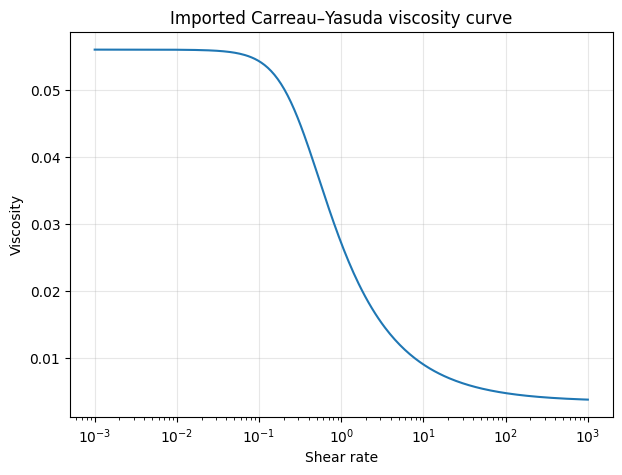

In [13]:
# ===============================================================
# CARREAU-YASUDA CURVE
# ===============================================================

gamma_curve = torch.logspace(
    -3,
    3,
    300,
    device=device,
)

with torch.no_grad():
    eta_curve = carreau_yasuda_viscosity(
        gamma_curve,
        eta0=cfg.eta0,
        eta_inf=cfg.eta_inf,
        lam=cfg.lam,
        n=cfg.n,
        a=cfg.a,
    )

gamma_np = gamma_curve.cpu().numpy()
eta_np = eta_curve.cpu().numpy()

print("Low-shear viscosity :", float(eta_np[0]))
print("High-shear viscosity:", float(eta_np[-1]))
print("eta0                :", cfg.eta0)
print("eta_inf             :", cfg.eta_inf)

if not eta_np[0] > eta_np[-1]:
    raise RuntimeError(
        "Expected shear-thinning behavior, but viscosity did not decrease."
    )

plt.figure(figsize=(7, 5))
plt.semilogx(gamma_np, eta_np)
plt.xlabel("Shear rate")
plt.ylabel("Viscosity")
plt.title("Imported Carreau–Yasuda viscosity curve")
plt.grid(True, alpha=0.3)
plt.show()

## Cell 13 — Interior, boundary, and centreline sampling

The inlet is now the independently computed fully developed Carreau–Yasuda reference profile.
The former Newtonian parabola is not used.

- **bottom wall:** `u = 0`, `v = 0`
- **top wall:** `u = 0`, `v = 0`
- **inlet:** bulk-matched CY reference `u(y)`, with `v = 0`
- **outlet:** gauge pressure `p = 0`
- **centreline (`y = 0.5`):** `v = 0`, `du/dy = 0`
- **mirrored pairs:** `u(x,y) = u(x,1-y)`, `v(x,y) = -v(x,1-y)`, and
  `du/dy(x,y) = -du/dy(x,1-y)`

Adam resamples all four point sets every step. L-BFGS receives dense fixed sets.


In [14]:
# ===============================================================
# SAMPLING + BOUNDARY/CENTRELINE/MIRROR OBJECTIVES
# ===============================================================

def sample_interior(n):
    x = (
        torch.rand(n, 1, device=device)
        * (cfg.x_max - cfg.x_min)
        + cfg.x_min
    )
    y = (
        torch.rand(n, 1, device=device)
        * (cfg.y_max - cfg.y_min)
        + cfg.y_min
    )
    return torch.cat([x, y], dim=1)


def sample_boundary(n_total):
    n_side = max(1, n_total // 4)

    x_bottom = (
        torch.rand(n_side, 1, device=device)
        * (cfg.x_max - cfg.x_min)
        + cfg.x_min
    )
    y_bottom = torch.full_like(x_bottom, cfg.y_min)
    bottom = torch.cat([x_bottom, y_bottom], dim=1)

    x_top = (
        torch.rand(n_side, 1, device=device)
        * (cfg.x_max - cfg.x_min)
        + cfg.x_min
    )
    y_top = torch.full_like(x_top, cfg.y_max)
    top = torch.cat([x_top, y_top], dim=1)

    y_inlet = (
        torch.rand(n_side, 1, device=device)
        * (cfg.y_max - cfg.y_min)
        + cfg.y_min
    )
    x_inlet = torch.full_like(y_inlet, cfg.x_min)
    inlet = torch.cat([x_inlet, y_inlet], dim=1)

    y_outlet = (
        torch.rand(n_side, 1, device=device)
        * (cfg.y_max - cfg.y_min)
        + cfg.y_min
    )
    x_outlet = torch.full_like(y_outlet, cfg.x_max)
    outlet = torch.cat([x_outlet, y_outlet], dim=1)

    return {
        "bottom": bottom,
        "top": top,
        "inlet": inlet,
        "outlet": outlet,
    }


def sample_centerline(n):
    x = (
        torch.rand(n, 1, device=device)
        * (cfg.x_max - cfg.x_min)
        + cfg.x_min
    )
    y_mid = 0.5 * (cfg.y_min + cfg.y_max)
    y = torch.full_like(x, y_mid)
    return torch.cat([x, y], dim=1)


def sample_mirror_pairs(n):
    """Sample paired points reflected across the channel centreline."""
    x = (
        torch.rand(n, 1, device=device)
        * (cfg.x_max - cfg.x_min)
        + cfg.x_min
    )
    y_mid = 0.5 * (cfg.y_min + cfg.y_max)
    y_lower = (
        torch.rand(n, 1, device=device)
        * (y_mid - cfg.y_min)
        + cfg.y_min
    )
    y_upper = cfg.y_min + cfg.y_max - y_lower

    xy_lower = torch.cat([x, y_lower], dim=1)
    xy_upper = torch.cat([x, y_upper], dim=1)
    return xy_lower, xy_upper


def inlet_target_u(y):
    """Interpolate the fixed CY reference at inlet boundary points."""
    y_np = y.detach().cpu().numpy().reshape(-1)
    u_np = np.interp(y_np, y_ref, u_ref)
    return torch.tensor(
        u_np,
        dtype=y.dtype,
        device=y.device,
    ).reshape(-1, 1)


def compute_boundary_loss_from_batch(model, bc):
    bottom_pred = model(bc["bottom"])
    top_pred = model(bc["top"])
    inlet_pred = model(bc["inlet"])
    outlet_pred = model(bc["outlet"])

    zeros_bottom = torch.zeros_like(bottom_pred[:, 0:1])
    zeros_top = torch.zeros_like(top_pred[:, 0:1])
    zeros_inlet = torch.zeros_like(inlet_pred[:, 0:1])
    zeros_outlet = torch.zeros_like(outlet_pred[:, 2:3])

    wall_loss = (
        mse(bottom_pred[:, 0:1], zeros_bottom)
        + mse(bottom_pred[:, 1:2], zeros_bottom)
        + mse(top_pred[:, 0:1], zeros_top)
        + mse(top_pred[:, 1:2], zeros_top)
    )

    inlet_u_target = inlet_target_u(bc["inlet"][:, 1:2])
    inlet_loss = (
        mse(inlet_pred[:, 0:1], inlet_u_target)
        + mse(inlet_pred[:, 1:2], zeros_inlet)
    )

    outlet_loss = mse(outlet_pred[:, 2:3], zeros_outlet)
    total_bc_loss = wall_loss + inlet_loss + outlet_loss
    components = {
        "wall": wall_loss,
        "inlet": inlet_loss,
        "outlet": outlet_loss,
    }
    return total_bc_loss, components


def compute_boundary_loss(model, n_boundary):
    return compute_boundary_loss_from_batch(
        model,
        sample_boundary(n_boundary),
    )


def compute_centerline_loss_from_batch(model, xy_centerline):
    xy = (
        xy_centerline
        .detach()
        .clone()
        .requires_grad_(True)
    )
    pred = model(xy)
    u = pred[:, 0:1]
    v = pred[:, 1:2]

    grad_u = torch.autograd.grad(
        u,
        xy,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
    )[0]
    du_dy = grad_u[:, 1:2]

    v_loss = torch.mean(v ** 2)
    shear_loss = torch.mean(du_dy ** 2)
    total_center_loss = v_loss + shear_loss
    return total_center_loss, {
        "v": v_loss,
        "du_dy": shear_loss,
    }


def compute_centerline_loss(model, n_points):
    return compute_centerline_loss_from_batch(
        model,
        sample_centerline(n_points),
    )


def compute_mirror_symmetry_loss_from_batch(
    model,
    xy_lower,
    xy_upper,
):
    """Enforce velocity and streamwise-slope mirror parity.

    No direct eta or gamma penalty is used: their symmetry follows from
    the mirrored velocity field and its mirrored transverse derivative.
    """
    lower_xy = (
        xy_lower
        .detach()
        .clone()
        .requires_grad_(True)
    )
    upper_xy = (
        xy_upper
        .detach()
        .clone()
        .requires_grad_(True)
    )

    lower = model(lower_xy)
    upper = model(upper_xy)

    u_lower = lower[:, 0:1]
    v_lower = lower[:, 1:2]
    u_upper = upper[:, 0:1]
    v_upper = upper[:, 1:2]

    grad_u_lower = torch.autograd.grad(
        u_lower,
        lower_xy,
        grad_outputs=torch.ones_like(u_lower),
        create_graph=True,
    )[0]
    grad_u_upper = torch.autograd.grad(
        u_upper,
        upper_xy,
        grad_outputs=torch.ones_like(u_upper),
        create_graph=True,
    )[0]

    du_dy_lower = grad_u_lower[:, 1:2]
    du_dy_upper = grad_u_upper[:, 1:2]

    loss_u = torch.mean((u_lower - u_upper) ** 2)
    loss_v = torch.mean((v_lower + v_upper) ** 2)
    loss_du_dy = torch.mean((du_dy_lower + du_dy_upper) ** 2)

    total_symmetry_loss = loss_u + loss_v + loss_du_dy
    return total_symmetry_loss, {
        "u": loss_u,
        "v": loss_v,
        "du_dy": loss_du_dy,
    }


def compute_mirror_symmetry_loss(model, n_points):
    xy_lower, xy_upper = sample_mirror_pairs(n_points)
    return compute_mirror_symmetry_loss_from_batch(
        model,
        xy_lower,
        xy_upper,
    )


## Cell 14 — Train with the imported **non-Newtonian Navier–Stokes residual**

This is the core Task 1.1 integration.

The training path is now:

```text
(x,y)
  ↓
PINN from models/pinn_core.py
  ↓
(u,v,p)
  ↓
physics/navier_stokes.py
  ↓
strain-rate tensor
  ↓
effective shear rate γ̇
  ↓
physics/carreau_yasuda.py
  ↓
local viscosity η(γ̇)
  ↓
non-Newtonian stress divergence
  ↓
continuity + x/y momentum residuals
  ↓
physics loss
  ↓
backpropagation
```

In [15]:
# ===============================================================
# TRAINING LOOP — ADAM
# ===============================================================

RUN_TRAINING = True


def adam_lr_for_step(step):
    if step < cfg.lr_drop_step:
        return cfg.learning_rate_initial
    return cfg.learning_rate_final


if RUN_TRAINING:
    model.train()
    first_step = start_step + 1

    if first_step > cfg.n_train_steps:
        print(
            f"Checkpoint is already at step {start_step}, "
            f"which is >= n_train_steps={cfg.n_train_steps}."
        )
        print("Adam stage is already complete.")
    else:
        for step in range(first_step, cfg.n_train_steps + 1):
            current_lr = adam_lr_for_step(step)
            for group in optimizer.param_groups:
                group["lr"] = current_lr

            optimizer.zero_grad(set_to_none=True)

            # Fresh interior points every Adam step.
            xy_f = sample_interior(cfg.n_collocation)
            (
                continuity,
                momentum_x,
                momentum_y,
                eta_field,
                gamma_dot_field,
            ) = compute_ns_residuals_nonnewtonian(
                model=model,
                xy=xy_f,
                rho=cfg.rho,
                eta0=cfg.eta0,
                eta_inf=cfg.eta_inf,
                lam=cfg.lam,
                n=cfg.n,
                a=cfg.a,
            )

            physics_loss = navier_stokes_physics_loss(
                continuity,
                momentum_x,
                momentum_y,
            )
            continuity_loss = torch.mean(continuity ** 2)
            momentum_x_loss = torch.mean(momentum_x ** 2)
            momentum_y_loss = torch.mean(momentum_y ** 2)

            # Fresh boundary, centreline, and mirror pairs every Adam step.
            boundary_loss, boundary_components = compute_boundary_loss(
                model,
                cfg.n_boundary,
            )
            centerline_loss, centerline_components = (
                compute_centerline_loss(
                    model,
                    cfg.n_centerline,
                )
            )
            symmetry_loss, symmetry_components = (
                compute_mirror_symmetry_loss(
                    model,
                    cfg.n_symmetry,
                )
            )

            total_loss = (
                physics_loss
                + cfg.boundary_weight * boundary_loss
                + cfg.center_weight * centerline_loss
                + cfg.symmetry_weight * symmetry_loss
            )

            if not torch.isfinite(total_loss):
                raise RuntimeError(f"Non-finite loss at step {step}.")

            total_loss.backward()
            optimizer.step()

            history["total"].append(total_loss.detach().item())
            history["physics"].append(physics_loss.detach().item())
            history["boundary"].append(boundary_loss.detach().item())
            history["centerline"].append(
                centerline_loss.detach().item()
            )
            history["symmetry"].append(
                symmetry_loss.detach().item()
            )
            history["continuity"].append(
                continuity_loss.detach().item()
            )
            history["momentum_x"].append(
                momentum_x_loss.detach().item()
            )
            history["momentum_y"].append(
                momentum_y_loss.detach().item()
            )
            history["eta_mean"].append(
                eta_field.detach().mean().item()
            )
            history["gamma_mean"].append(
                gamma_dot_field.detach().mean().item()
            )

            if (
                step == first_step
                or step % cfg.print_every == 0
                or step == cfg.n_train_steps
            ):
                print(
                    f"step={step:5d} | "
                    f"lr={current_lr:.1e} | "
                    f"total={total_loss.item():.3e} | "
                    f"physics={physics_loss.item():.3e} | "
                    f"bc={boundary_loss.item():.3e} | "
                    f"center={centerline_loss.item():.3e} | "
                    f"mirror={symmetry_loss.item():.3e} | "
                    f"cont={continuity_loss.item():.3e} | "
                    f"mx={momentum_x_loss.item():.3e} | "
                    f"my={momentum_y_loss.item():.3e} | "
                    f"eta={eta_field.detach().mean().item():.4e} | "
                    f"gamma={gamma_dot_field.detach().mean().item():.4e}"
                )

            if (
                step % cfg.save_every == 0
                or step == cfg.n_train_steps
            ):
                save_checkpoint(
                    CHECKPOINT_PATH,
                    step,
                    model,
                    optimizer,
                    history,
                )

        start_step = cfg.n_train_steps
else:
    print("Training skipped.")


step=    1 | lr=1.0e-03 | total=4.174e+00 | physics=3.051e-03 | bc=4.096e-01 | center=5.660e-03 | mirror=2.317e-02 | cont=2.116e-03 | mx=5.380e-04 | my=3.973e-04 | eta=5.4148e-02 | gamma=1.0317e-01
step=  100 | lr=1.0e-03 | total=1.475e+00 | physics=2.112e-01 | bc=1.210e-01 | center=3.850e-04 | mirror=2.587e-02 | cont=2.010e-01 | mx=6.424e-03 | my=3.748e-03 | eta=3.3693e-02 | gamma=7.3593e-01
step=  200 | lr=1.0e-03 | total=1.243e-01 | physics=3.543e-02 | bc=7.540e-03 | center=3.694e-04 | mirror=5.810e-03 | cont=3.132e-02 | mx=3.789e-03 | my=3.205e-04 | eta=2.3037e-02 | gamma=1.7187e+00
step=  300 | lr=1.0e-03 | total=6.851e-02 | physics=1.716e-02 | bc=5.030e-03 | center=4.537e-05 | mirror=4.136e-04 | cont=1.018e-02 | mx=6.790e-03 | my=1.896e-04 | eta=2.3445e-02 | gamma=1.8045e+00
step=  400 | lr=1.0e-03 | total=6.549e-02 | physics=1.219e-02 | bc=5.198e-03 | center=5.052e-05 | mirror=5.368e-04 | cont=5.063e-03 | mx=6.989e-03 | my=1.336e-04 | eta=2.3528e-02 | gamma=1.8719e+00
step=  500

## Cell 14B — Dense deterministic L-BFGS refinement

L-BFGS refines the Adam solution on fixed sets of 8,192 interior points, 1,024 boundary points,
512 centreline points, and 1,024 mirrored pairs. Keeping every part of the closure fixed is
required for a consistent line search. The objective includes the same CY inlet, centreline, and
whole-channel mirror terms used by Adam.

A separate refined checkpoint preserves the Adam checkpoint/resume workflow.


In [16]:
# ===============================================================
# DETERMINISTIC L-BFGS REFINEMENT
# ===============================================================

REFINED_CHECKPOINT_PATH = (
    CHECKPOINT_DIR
    / "task_1_1_cy_ns_mirror_symmetry_lbfgs.pt"
)

RUN_LBFGS_REFINEMENT = cfg.run_lbfgs
refined_loaded = False
lbfgs_trace = []

if RUN_LBFGS_REFINEMENT and REFINED_CHECKPOINT_PATH.exists():
    refined_checkpoint = torch.load(
        REFINED_CHECKPOINT_PATH,
        map_location="cpu",
        weights_only=False,
    )
    same_adam_step = (
        int(refined_checkpoint.get("adam_step", -1))
        == int(start_step)
    )
    same_cfg = refined_checkpoint.get("cfg", {}) == asdict(cfg)

    if same_adam_step and same_cfg:
        model.load_state_dict(
            refined_checkpoint["model_state_dict"]
        )
        model.to(device)
        lbfgs_trace = refined_checkpoint.get("lbfgs_trace", [])
        refined_loaded = True
        print(
            "Loaded compatible L-BFGS-refined checkpoint:",
            REFINED_CHECKPOINT_PATH,
        )
    else:
        print(
            "Existing refined checkpoint does not match the current "
            "Adam step/configuration; it will be regenerated."
        )


if RUN_LBFGS_REFINEMENT and not refined_loaded:
    if start_step < cfg.n_train_steps:
        print(
            "Skipping L-BFGS because the Adam stage has not reached "
            f"{cfg.n_train_steps} steps."
        )
    else:
        model.train()

        # Fixed points: never resample inside the L-BFGS closure.
        xy_lbfgs = sample_interior(cfg.lbfgs_collocation).detach()
        bc_lbfgs = {
            key: value.detach()
            for key, value in sample_boundary(
                cfg.lbfgs_boundary
            ).items()
        }
        center_lbfgs = sample_centerline(
            cfg.lbfgs_centerline
        ).detach()
        sym_lower_lbfgs, sym_upper_lbfgs = sample_mirror_pairs(
            cfg.lbfgs_symmetry
        )
        sym_lower_lbfgs = sym_lower_lbfgs.detach()
        sym_upper_lbfgs = sym_upper_lbfgs.detach()

        lbfgs_optimizer = torch.optim.LBFGS(
            model.parameters(),
            lr=cfg.lbfgs_lr,
            max_iter=cfg.lbfgs_max_iter,
            history_size=cfg.lbfgs_history_size,
            line_search_fn="strong_wolfe",
            tolerance_grad=1e-9,
            tolerance_change=1e-12,
        )

        lbfgs_state = {"closure_calls": 0}

        def lbfgs_closure():
            lbfgs_state["closure_calls"] += 1
            closure_calls = lbfgs_state["closure_calls"]
            lbfgs_optimizer.zero_grad(set_to_none=True)

            (
                continuity_l,
                momentum_x_l,
                momentum_y_l,
                _,
                _,
            ) = compute_ns_residuals_nonnewtonian(
                model=model,
                xy=xy_lbfgs,
                rho=cfg.rho,
                eta0=cfg.eta0,
                eta_inf=cfg.eta_inf,
                lam=cfg.lam,
                n=cfg.n,
                a=cfg.a,
            )
            physics_l = navier_stokes_physics_loss(
                continuity_l,
                momentum_x_l,
                momentum_y_l,
            )
            boundary_l, _ = compute_boundary_loss_from_batch(
                model,
                bc_lbfgs,
            )
            centerline_l, _ = compute_centerline_loss_from_batch(
                model,
                center_lbfgs,
            )
            symmetry_l, _ = compute_mirror_symmetry_loss_from_batch(
                model,
                sym_lower_lbfgs,
                sym_upper_lbfgs,
            )

            total_l = (
                physics_l
                + cfg.boundary_weight * boundary_l
                + cfg.center_weight * centerline_l
                + cfg.symmetry_weight * symmetry_l
            )
            if not torch.isfinite(total_l):
                raise RuntimeError(
                    "Non-finite loss during L-BFGS refinement."
                )

            total_l.backward()
            lbfgs_trace.append({
                "closure": closure_calls,
                "total": float(total_l.detach().item()),
                "physics": float(physics_l.detach().item()),
                "boundary": float(boundary_l.detach().item()),
                "centerline": float(centerline_l.detach().item()),
                "symmetry": float(symmetry_l.detach().item()),
            })

            if closure_calls == 1 or closure_calls % 25 == 0:
                print(
                    f"L-BFGS closure={closure_calls:4d} | "
                    f"total={total_l.item():.3e} | "
                    f"physics={physics_l.item():.3e} | "
                    f"bc={boundary_l.item():.3e} | "
                    f"center={centerline_l.item():.3e} | "
                    f"mirror={symmetry_l.item():.3e}"
                )
            return total_l

        lbfgs_optimizer.step(lbfgs_closure)

        torch.save(
            {
                "adam_step": int(start_step),
                "model_state_dict": model.state_dict(),
                "lbfgs_trace": lbfgs_trace,
                "cfg": asdict(cfg),
            },
            REFINED_CHECKPOINT_PATH,
        )
        print(
            "Saved L-BFGS-refined checkpoint:",
            REFINED_CHECKPOINT_PATH,
        )

        del (
            xy_lbfgs,
            bc_lbfgs,
            center_lbfgs,
            sym_lower_lbfgs,
            sym_upper_lbfgs,
            lbfgs_optimizer,
        )
elif not RUN_LBFGS_REFINEMENT:
    print("L-BFGS refinement disabled in cfg.")

model.eval()


L-BFGS closure=   1 | total=6.061e-04 | physics=3.892e-04 | bc=6.443e-06 | center=1.301e-06 | mirror=7.301e-05
L-BFGS closure=  25 | total=5.764e-04 | physics=3.770e-04 | bc=6.554e-06 | center=2.288e-06 | mirror=6.118e-05
L-BFGS closure=  50 | total=3.864e-04 | physics=2.745e-04 | bc=7.144e-06 | center=8.983e-07 | mirror=1.799e-05
L-BFGS closure=  75 | total=3.525e-04 | physics=2.700e-04 | bc=5.131e-06 | center=1.319e-06 | mirror=1.228e-05
L-BFGS closure= 100 | total=3.194e-04 | physics=2.507e-04 | bc=4.951e-06 | center=1.174e-07 | mirror=9.306e-06
L-BFGS closure= 125 | total=2.531e-04 | physics=1.664e-04 | bc=6.959e-06 | center=1.467e-07 | mirror=8.183e-06
L-BFGS closure= 150 | total=2.242e-04 | physics=1.509e-04 | bc=5.044e-06 | center=6.749e-07 | mirror=9.715e-06
L-BFGS closure= 175 | total=1.920e-04 | physics=1.430e-04 | bc=3.186e-06 | center=3.360e-07 | mirror=7.747e-06
L-BFGS closure= 200 | total=1.664e-04 | physics=1.333e-04 | bc=2.410e-06 | center=2.976e-08 | mirror=4.394e-06
L

PINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=3, bias=True)
  )
)

## Cell 15 — Training-loss plots

What to look for:

- total loss should generally decrease;
- physics loss should decrease;
- boundary loss should decrease;
- continuity and both momentum losses should remain finite.

Do not judge success from total loss alone. A low total loss with one large PDE component can hide
an imbalance.

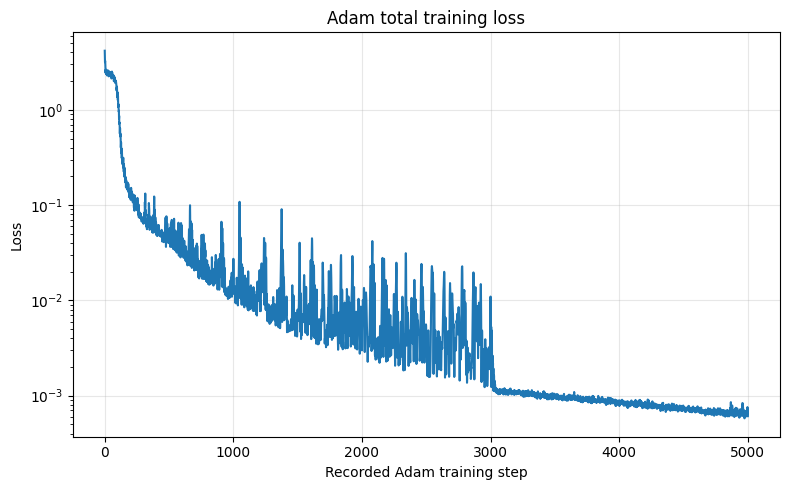

Saved: /kaggle/working/rheolnet_outputs/total_history.png


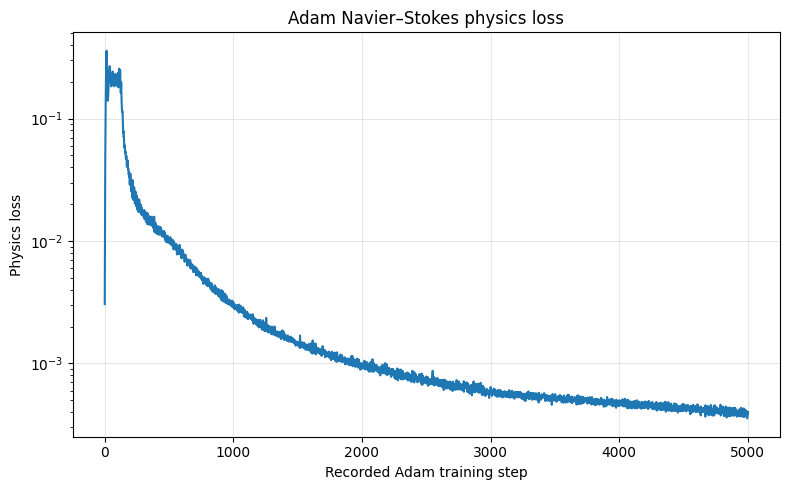

Saved: /kaggle/working/rheolnet_outputs/physics_history.png


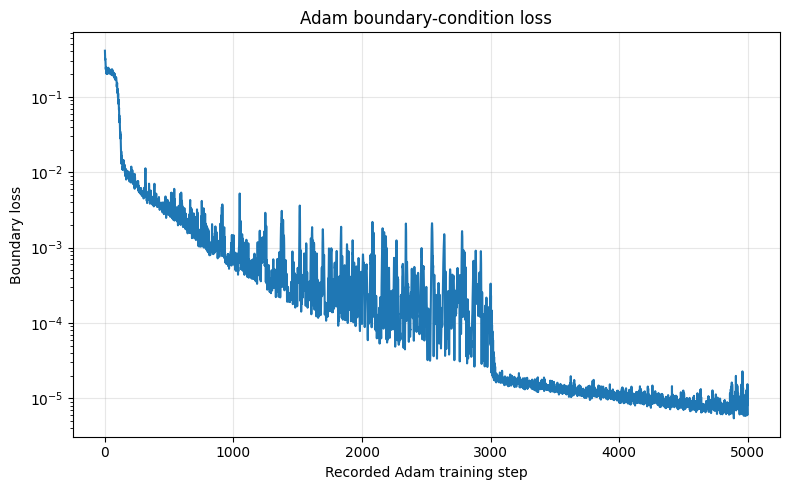

Saved: /kaggle/working/rheolnet_outputs/boundary_history.png


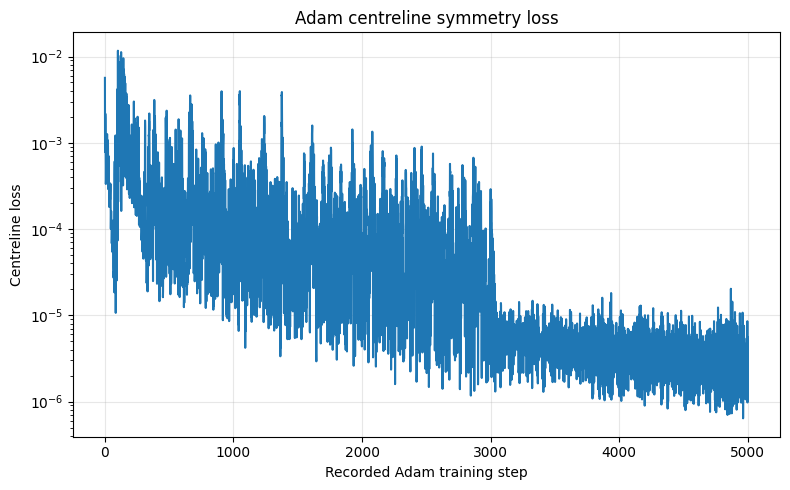

Saved: /kaggle/working/rheolnet_outputs/centerline_history.png


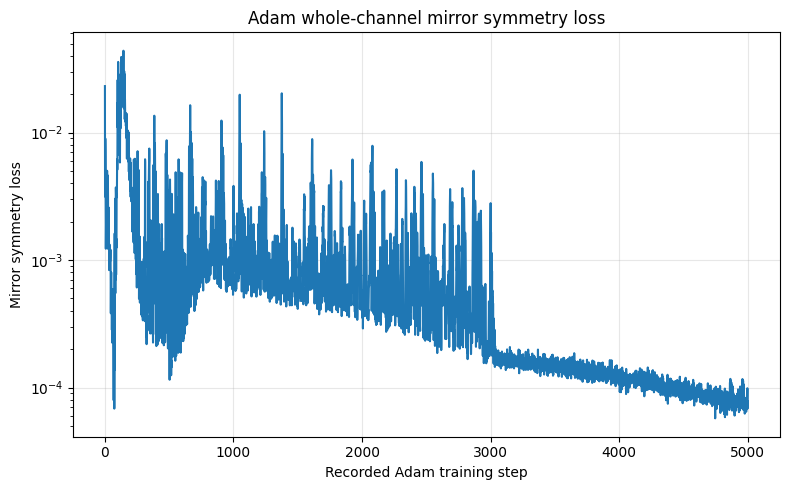

Saved: /kaggle/working/rheolnet_outputs/symmetry_history.png


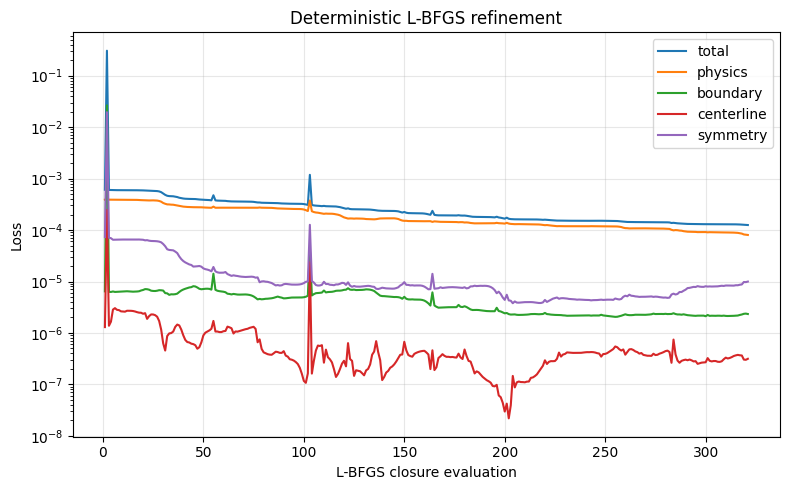

Saved: /kaggle/working/rheolnet_outputs/lbfgs_refinement_loss.png


In [17]:
# ===============================================================
# LOSS PLOTS
# ===============================================================

OUTPUT_DIR = Path("/kaggle/working/rheolnet_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def plot_history_series(key, title, ylabel):
    values = history.get(key, [])
    if len(values) == 0:
        print(f"No history available for {key}.")
        return

    plt.figure(figsize=(8, 5))
    plt.semilogy(np.arange(1, len(values) + 1), values)
    plt.xlabel("Recorded Adam training step")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_path = OUTPUT_DIR / f"{key}_history.png"
    plt.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", save_path)


plot_history_series("total", "Adam total training loss", "Loss")
plot_history_series(
    "physics",
    "Adam Navier–Stokes physics loss",
    "Physics loss",
)
plot_history_series(
    "boundary",
    "Adam boundary-condition loss",
    "Boundary loss",
)
plot_history_series(
    "centerline",
    "Adam centreline symmetry loss",
    "Centreline loss",
)
plot_history_series(
    "symmetry",
    "Adam whole-channel mirror symmetry loss",
    "Mirror symmetry loss",
)


if len(lbfgs_trace) > 0:
    closure_index = np.array([
        item["closure"] for item in lbfgs_trace
    ])
    series = {
        "total": np.array([item["total"] for item in lbfgs_trace]),
        "physics": np.array([
            item["physics"] for item in lbfgs_trace
        ]),
        "boundary": np.array([
            item["boundary"] for item in lbfgs_trace
        ]),
        "centerline": np.array([
            item.get("centerline", np.nan)
            for item in lbfgs_trace
        ]),
        "symmetry": np.array([
            item.get("symmetry", np.nan)
            for item in lbfgs_trace
        ]),
    }

    plt.figure(figsize=(8, 5))
    for label, values in series.items():
        plt.semilogy(closure_index, values, label=label)
    plt.xlabel("L-BFGS closure evaluation")
    plt.ylabel("Loss")
    plt.title("Deterministic L-BFGS refinement")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    lbfgs_plot_path = OUTPUT_DIR / "lbfgs_refinement_loss.png"
    plt.savefig(lbfgs_plot_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", lbfgs_plot_path)
else:
    print("No L-BFGS trace available.")


## Cell 16 — Residual diagnostics on fresh interior points

RMS residuals give a more interpretable PDE diagnostic than only viewing the scalar weighted loss.

FRESH-POINT PDE DIAGNOSTICS
Points tested   : 10000
RMS continuity : 3.897579e-03
RMS momentum x : 7.866408e-03
RMS momentum y : 2.552778e-03
eta min        : 1.189921e-02
eta max        : 5.599917e-02
gamma min      : 2.113200e-03
gamma max      : 5.205818e+00
------------------------------------------------------------------------------
continuity  : PASS (target < 1.0e-02)
momentum_x  : PASS (target < 1.0e-02)
momentum_y  : PASS (target < 1.0e-02)


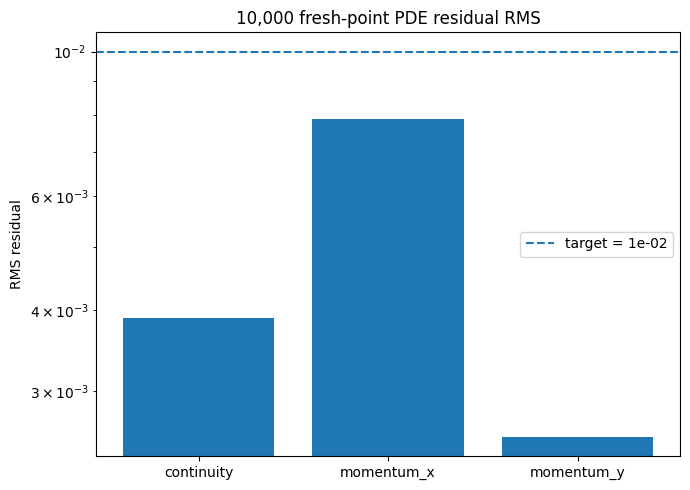

Saved: /kaggle/working/rheolnet_outputs/fresh_point_residual_rms.png


In [18]:
# ===============================================================
# FRESH-POINT RESIDUAL DIAGNOSTICS
# ===============================================================

model.eval()


def fresh_point_residual_diagnostics(
    n_points,
    batch_size=1024,
):
    sum_sq = {
        "continuity": 0.0,
        "momentum_x": 0.0,
        "momentum_y": 0.0,
    }
    eta_min = float("inf")
    eta_max = float("-inf")
    gamma_min = float("inf")
    gamma_max = float("-inf")
    n_seen = 0

    while n_seen < n_points:
        n_batch = min(batch_size, n_points - n_seen)
        xy_diag = sample_interior(n_batch)
        (
            continuity_diag,
            momentum_x_diag,
            momentum_y_diag,
            eta_diag,
            gamma_diag,
        ) = compute_ns_residuals_nonnewtonian(
            model=model,
            xy=xy_diag,
            rho=cfg.rho,
            eta0=cfg.eta0,
            eta_inf=cfg.eta_inf,
            lam=cfg.lam,
            n=cfg.n,
            a=cfg.a,
        )

        residuals = {
            "continuity": continuity_diag,
            "momentum_x": momentum_x_diag,
            "momentum_y": momentum_y_diag,
        }
        for key, value in residuals.items():
            sum_sq[key] += float(
                torch.sum(value.detach() ** 2).item()
            )

        eta_det = eta_diag.detach()
        gamma_det = gamma_diag.detach()
        eta_min = min(eta_min, float(eta_det.min().item()))
        eta_max = max(eta_max, float(eta_det.max().item()))
        gamma_min = min(gamma_min, float(gamma_det.min().item()))
        gamma_max = max(gamma_max, float(gamma_det.max().item()))
        n_seen += n_batch

    rms = {
        key: math.sqrt(value / n_seen)
        for key, value in sum_sq.items()
    }
    return {
        **rms,
        "eta_min": eta_min,
        "eta_max": eta_max,
        "gamma_min": gamma_min,
        "gamma_max": gamma_max,
        "n_points": n_seen,
    }


# These 10,000 points are sampled only after optimization and never train it.
fresh_diag = fresh_point_residual_diagnostics(
    n_points=cfg.validation_points,
)
rms_cont = fresh_diag["continuity"]
rms_mx = fresh_diag["momentum_x"]
rms_my = fresh_diag["momentum_y"]

print("=" * 78)
print("FRESH-POINT PDE DIAGNOSTICS")
print("=" * 78)
print("Points tested   :", fresh_diag["n_points"])
print(f"RMS continuity : {rms_cont:.6e}")
print(f"RMS momentum x : {rms_mx:.6e}")
print(f"RMS momentum y : {rms_my:.6e}")
print(f"eta min        : {fresh_diag['eta_min']:.6e}")
print(f"eta max        : {fresh_diag['eta_max']:.6e}")
print(f"gamma min      : {fresh_diag['gamma_min']:.6e}")
print(f"gamma max      : {fresh_diag['gamma_max']:.6e}")
print("-" * 78)

residual_gate = {
    "continuity": rms_cont < cfg.residual_rms_target,
    "momentum_x": rms_mx < cfg.residual_rms_target,
    "momentum_y": rms_my < cfg.residual_rms_target,
}
for key, passed in residual_gate.items():
    symbol = "PASS" if passed else "NEEDS MORE CONVERGENCE"
    print(
        f"{key:12s}: {symbol} "
        f"(target < {cfg.residual_rms_target:.1e})"
    )
print("=" * 78)

plt.figure(figsize=(7, 5))
plt.bar(
    ["continuity", "momentum_x", "momentum_y"],
    [rms_cont, rms_mx, rms_my],
)
plt.axhline(
    cfg.residual_rms_target,
    linestyle="--",
    label=f"target = {cfg.residual_rms_target:.0e}",
)
plt.yscale("log")
plt.ylabel("RMS residual")
plt.title("10,000 fresh-point PDE residual RMS")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
residual_plot_path = OUTPUT_DIR / "fresh_point_residual_rms.png"
plt.savefig(residual_plot_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", residual_plot_path)


## Cell 17 — Velocity and pressure profiles across the channel

The cross-section is sampled at `x = 0.5`.

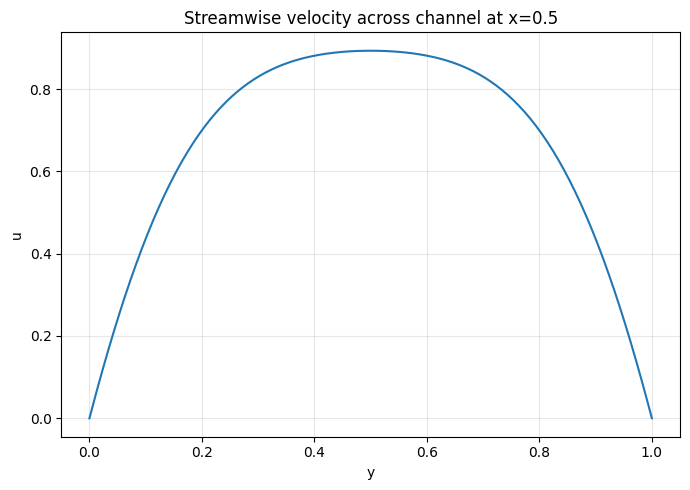

Saved: /kaggle/working/rheolnet_outputs/u_profile_midchannel.png


In [19]:
# ===============================================================
# CROSS-SECTION: u(y)
# ===============================================================

model.eval()

# Odd number includes the exact channel centreline.
n_profile = 301

y_profile = torch.linspace(
    cfg.y_min,
    cfg.y_max,
    n_profile,
    device=device,
).reshape(-1, 1)

x_mid = 0.5 * (
    cfg.x_min + cfg.x_max
)

y_mid = 0.5 * (
    cfg.y_min + cfg.y_max
)

x_profile = torch.full_like(
    y_profile,
    x_mid,
)

xy_profile = torch.cat(
    [x_profile, y_profile],
    dim=1,
)

with torch.no_grad():
    pred_profile = model(xy_profile)

u_profile = pred_profile[:, 0].cpu().numpy()
v_profile = pred_profile[:, 1].cpu().numpy()
p_profile = pred_profile[:, 2].cpu().numpy()
y_profile_np = y_profile[:, 0].cpu().numpy()

centre_idx = int(
    np.argmin(
        np.abs(y_profile_np - y_mid)
    )
)

plt.figure(figsize=(7, 5))
plt.plot(y_profile_np, u_profile)
plt.xlabel("y")
plt.ylabel("u")
plt.title(
    f"Streamwise velocity across channel at x={x_mid:.3g}"
)
plt.grid(True, alpha=0.3)
plt.tight_layout()

u_profile_path = OUTPUT_DIR / "u_profile_midchannel.png"
plt.savefig(
    u_profile_path,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print("Saved:", u_profile_path)


max|v| / max|u| = 4.250158e-04
Transverse-velocity gate: PASS (target < 1.0e-03)


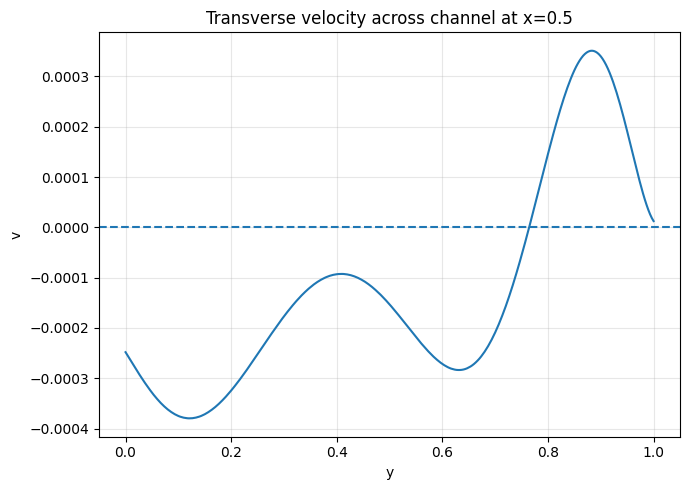

Saved: /kaggle/working/rheolnet_outputs/v_profile_midchannel.png


In [20]:
# ===============================================================
# CROSS-SECTION: v(y) + DIRECT TRANSVERSE-VELOCITY CHECK
# ===============================================================

u_scale_profile = max(float(np.max(np.abs(u_profile))), 1e-12)
v_ratio = float(np.max(np.abs(v_profile)) / u_scale_profile)

print(f"max|v| / max|u| = {v_ratio:.6e}")
print(
    "Transverse-velocity gate:",
    "PASS" if v_ratio < cfg.v_to_u_target else "REVIEW",
    f"(target < {cfg.v_to_u_target:.1e})",
)

plt.figure(figsize=(7, 5))
plt.plot(y_profile_np, v_profile)
plt.axhline(0.0, linestyle="--")
plt.xlabel("y")
plt.ylabel("v")
plt.title(
    f"Transverse velocity across channel at x={x_mid:.3g}"
)
plt.grid(True, alpha=0.3)
plt.tight_layout()
v_profile_path = OUTPUT_DIR / "v_profile_midchannel.png"
plt.savefig(v_profile_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", v_profile_path)


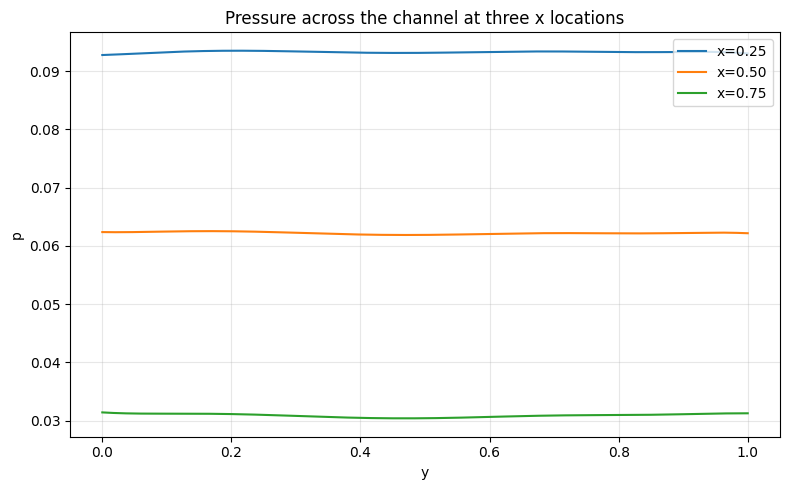

Saved: /kaggle/working/rheolnet_outputs/pressure_across_y.png
Cross-stream pressure diagnostics
x=0.25 | max(p)-min(p)=7.402152e-04 | max|dp/dy|=9.336352e-03
x=0.50 | max(p)-min(p)=6.587543e-04 | max|dp/dy|=4.574738e-03
x=0.75 | max(p)-min(p)=1.019619e-03 | max|dp/dy|=6.760577e-03
Worst cross-stream pressure range: 1.019619e-03
Worst max |dp/dy|              : 9.336352e-03


In [21]:
# ===============================================================
# PRESSURE ACROSS y AT x = 0.25, 0.50, 0.75
# ===============================================================

pressure_x_locations = [0.25, 0.50, 0.75]
pressure_profiles = {}
pressure_cross_spans = {}
pressure_max_abs_dpdy = {}

plt.figure(figsize=(8, 5))
for x_value in pressure_x_locations:
    y_pressure = torch.linspace(
        cfg.y_min,
        cfg.y_max,
        n_profile,
        device=device,
    ).reshape(-1, 1)
    x_pressure = torch.full_like(y_pressure, x_value)
    xy_pressure_y = torch.cat(
        [x_pressure, y_pressure],
        dim=1,
    ).requires_grad_(True)

    pred_pressure_y = model(xy_pressure_y)
    p_pressure_y = pred_pressure_y[:, 2:3]
    grad_p_y = torch.autograd.grad(
        p_pressure_y,
        xy_pressure_y,
        grad_outputs=torch.ones_like(p_pressure_y),
        create_graph=False,
        retain_graph=False,
    )[0]

    p_values = (
        p_pressure_y[:, 0]
        .detach()
        .cpu()
        .numpy()
    )
    dpdy_values = (
        grad_p_y[:, 1]
        .detach()
        .cpu()
        .numpy()
    )
    pressure_profiles[x_value] = p_values
    pressure_cross_spans[x_value] = float(np.ptp(p_values))
    pressure_max_abs_dpdy[x_value] = float(
        np.max(np.abs(dpdy_values))
    )
    plt.plot(
        y_profile_np,
        p_values,
        label=f"x={x_value:.2f}",
    )

plt.xlabel("y")
plt.ylabel("p")
plt.title("Pressure across the channel at three x locations")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
pressure_y_path = OUTPUT_DIR / "pressure_across_y.png"
plt.savefig(pressure_y_path, dpi=200, bbox_inches="tight")
plt.show()

cross_pressure_range = max(pressure_cross_spans.values())
max_abs_dpdy = max(pressure_max_abs_dpdy.values())

print("Saved:", pressure_y_path)
print("Cross-stream pressure diagnostics")
for x_value in pressure_x_locations:
    print(
        f"x={x_value:.2f} | "
        f"max(p)-min(p)={pressure_cross_spans[x_value]:.6e} | "
        f"max|dp/dy|={pressure_max_abs_dpdy[x_value]:.6e}"
    )
print(f"Worst cross-stream pressure range: {cross_pressure_range:.6e}")
print(f"Worst max |dp/dy|              : {max_abs_dpdy:.6e}")


## Cell 17B — Pressure along the channel centreline

For nearly fully developed straight-channel flow, pressure should vary primarily in the streamwise direction. This plot directly checks the missing axial pressure trend identified in the review and reports how close it is to a linear pressure drop.


CENTRELINE PRESSURE DIAGNOSTICS
p(x_min)                 : 1.235108e-01
p(x_max)                 : -7.113963e-04
axial pressure range     : 1.242222e-01
linear-fit slope         : -1.248676e-01
mean dp/dx (autograd)    : -1.242112e-01
std dp/dx  (autograd)    : 1.840266e-03
p(x) linearity R^2       : 0.999974
cross/axial pressure span: 8.208028e-03


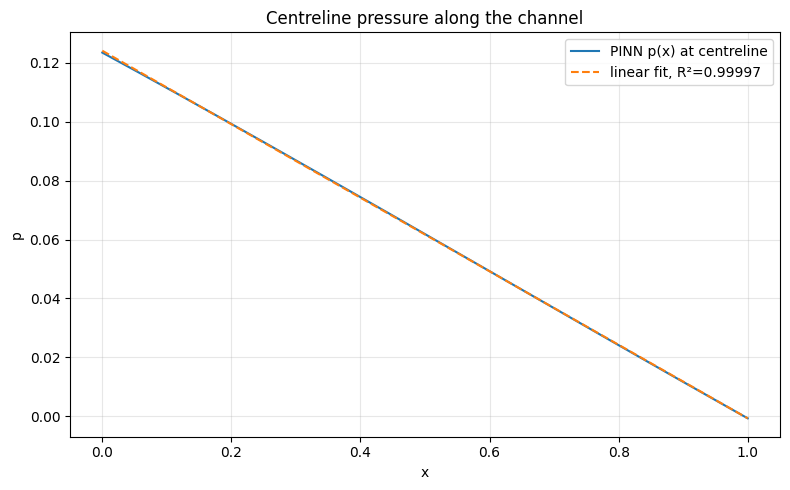

Saved: /kaggle/working/rheolnet_outputs/pressure_centreline_vs_x.png


In [22]:
# ===============================================================
# CENTRELINE PRESSURE: p(x)
# ===============================================================

n_axial = 301

x_axial = torch.linspace(
    cfg.x_min,
    cfg.x_max,
    n_axial,
    device=device,
).reshape(-1, 1)

y_axial = torch.full_like(
    x_axial,
    y_mid,
)

xy_axial = torch.cat(
    [x_axial, y_axial],
    dim=1,
).requires_grad_(True)

pred_axial = model(xy_axial)
p_axial_t = pred_axial[:, 2:3]

grad_p_axial = torch.autograd.grad(
    p_axial_t,
    xy_axial,
    grad_outputs=torch.ones_like(p_axial_t),
    create_graph=False,
    retain_graph=False,
)[0]

x_axial_np = x_axial[:, 0].detach().cpu().numpy()
p_axial = p_axial_t[:, 0].detach().cpu().numpy()
dpdx_axial = grad_p_axial[:, 0].detach().cpu().numpy()

linear_coeff = np.polyfit(
    x_axial_np,
    p_axial,
    deg=1,
)
p_linear = np.polyval(
    linear_coeff,
    x_axial_np,
)

ss_res = float(
    np.sum((p_axial - p_linear) ** 2)
)
ss_tot = float(
    np.sum(
        (p_axial - np.mean(p_axial)) ** 2
    )
)

pressure_linearity_r2 = (
    1.0 - ss_res / ss_tot
    if ss_tot > 1e-16
    else 1.0
)

axial_pressure_range = float(
    np.ptp(p_axial)
)

pressure_cross_to_axial = (
    cross_pressure_range / axial_pressure_range
    if axial_pressure_range > 1e-12
    else float("inf")
)

print("=" * 78)
print("CENTRELINE PRESSURE DIAGNOSTICS")
print("=" * 78)
print(f"p(x_min)                 : {p_axial[0]:.6e}")
print(f"p(x_max)                 : {p_axial[-1]:.6e}")
print(f"axial pressure range     : {axial_pressure_range:.6e}")
print(f"linear-fit slope         : {linear_coeff[0]:.6e}")
print(f"mean dp/dx (autograd)    : {np.mean(dpdx_axial):.6e}")
print(f"std dp/dx  (autograd)    : {np.std(dpdx_axial):.6e}")
print(f"p(x) linearity R^2       : {pressure_linearity_r2:.6f}")
print(f"cross/axial pressure span: {pressure_cross_to_axial:.6e}")
print("=" * 78)

plt.figure(figsize=(8, 5))
plt.plot(
    x_axial_np,
    p_axial,
    label="PINN p(x) at centreline",
)
plt.plot(
    x_axial_np,
    p_linear,
    linestyle="--",
    label=f"linear fit, R²={pressure_linearity_r2:.5f}",
)
plt.xlabel("x")
plt.ylabel("p")
plt.title("Centreline pressure along the channel")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

pressure_x_path = (
    OUTPUT_DIR / "pressure_centreline_vs_x.png"
)
plt.savefig(
    pressure_x_path,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print("Saved:", pressure_x_path)


## Cell 18 — Task-required viscosity profile and shear-rate profile

This cell calls the imported Navier–Stokes residual again so that `eta` and `gamma_dot`
come from exactly the same code path used during training.

Expected shear-thinning behavior:

```text
higher shear
    ↓
lower local viscosity

lower shear
    ↓
higher local viscosity
```

EXACT CENTRE/WALL CARREAU-YASUDA DIAGNOSTICS
gamma_center      : 1.763657e-03
gamma_wall_bottom : 5.212855e+00
gamma_wall_top    : 5.206403e+00
Centre viscosity  : 5.599942e-02
Bottom viscosity  : 1.189194e-02
Top viscosity     : 1.189861e-02
Centre eta error vs eta0: 0.001%


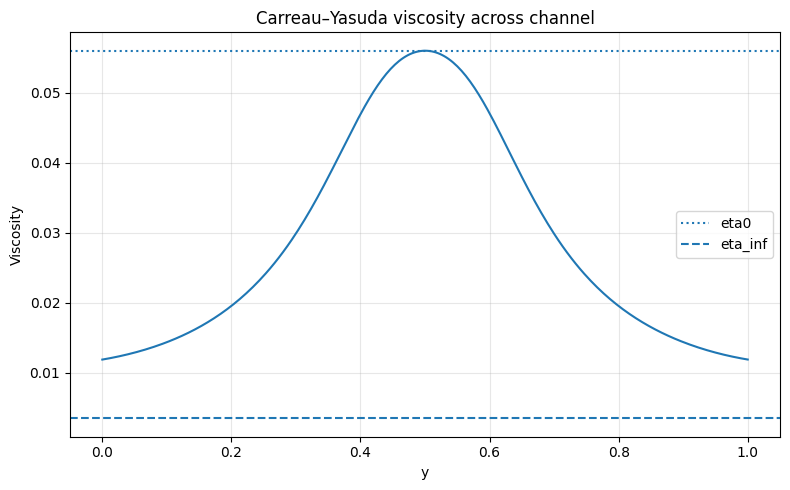

Saved: /kaggle/working/rheolnet_outputs/viscosity_day2.png


In [23]:
# ===============================================================
# VISCOSITY / SHEAR-RATE PROFILE + EXACT CENTRE/WALL CHECKS
# ===============================================================

xy_profile_grad = (
    xy_profile
    .clone()
    .detach()
    .requires_grad_(True)
)
(
    continuity_profile,
    momentum_x_profile,
    momentum_y_profile,
    eta_profile,
    gamma_profile,
) = compute_ns_residuals_nonnewtonian(
    model=model,
    xy=xy_profile_grad,
    rho=cfg.rho,
    eta0=cfg.eta0,
    eta_inf=cfg.eta_inf,
    lam=cfg.lam,
    n=cfg.n,
    a=cfg.a,
)

eta_profile_np = eta_profile.detach().squeeze().cpu().numpy()
gamma_profile_np = gamma_profile.detach().squeeze().cpu().numpy()

# Evaluate the exact centre and both exact walls, rather than using a
# profile minimum that may occur away from y=0.5.
xy_shear_exact = torch.tensor(
    [
        [x_mid, y_mid],
        [x_mid, cfg.y_min],
        [x_mid, cfg.y_max],
    ],
    dtype=torch.get_default_dtype(),
    device=device,
    requires_grad=True,
)
(
    _,
    _,
    _,
    eta_exact,
    gamma_exact,
) = compute_ns_residuals_nonnewtonian(
    model=model,
    xy=xy_shear_exact,
    rho=cfg.rho,
    eta0=cfg.eta0,
    eta_inf=cfg.eta_inf,
    lam=cfg.lam,
    n=cfg.n,
    a=cfg.a,
)

eta_exact_np = eta_exact.detach().reshape(-1).cpu().numpy()
gamma_exact_np = gamma_exact.detach().reshape(-1).cpu().numpy()

centre_eta = float(eta_exact_np[0])
centre_gamma = float(gamma_exact_np[0])
gamma_wall_bottom = float(gamma_exact_np[1])
gamma_wall_top = float(gamma_exact_np[2])
wall_gamma_max = max(
    abs(gamma_wall_bottom),
    abs(gamma_wall_top),
)

print("=" * 72)
print("EXACT CENTRE/WALL CARREAU-YASUDA DIAGNOSTICS")
print("=" * 72)
print(f"gamma_center      : {centre_gamma:.6e}")
print(f"gamma_wall_bottom : {gamma_wall_bottom:.6e}")
print(f"gamma_wall_top    : {gamma_wall_top:.6e}")
print(f"Centre viscosity  : {centre_eta:.6e}")
print(f"Bottom viscosity  : {eta_exact_np[1]:.6e}")
print(f"Top viscosity     : {eta_exact_np[2]:.6e}")
print(
    f"Centre eta error vs eta0: "
    f"{abs(centre_eta - cfg.eta0) / cfg.eta0:.3%}"
)
print("=" * 72)

plt.figure(figsize=(8, 5))
plt.plot(y_profile_np, eta_profile_np)
plt.axhline(cfg.eta0, linestyle=":", label="eta0")
plt.axhline(cfg.eta_inf, linestyle="--", label="eta_inf")
plt.xlabel("y")
plt.ylabel("Viscosity")
plt.title("Carreau–Yasuda viscosity across channel")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
viscosity_plot_path = OUTPUT_DIR / "viscosity_day2.png"
plt.savefig(viscosity_plot_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", viscosity_plot_path)


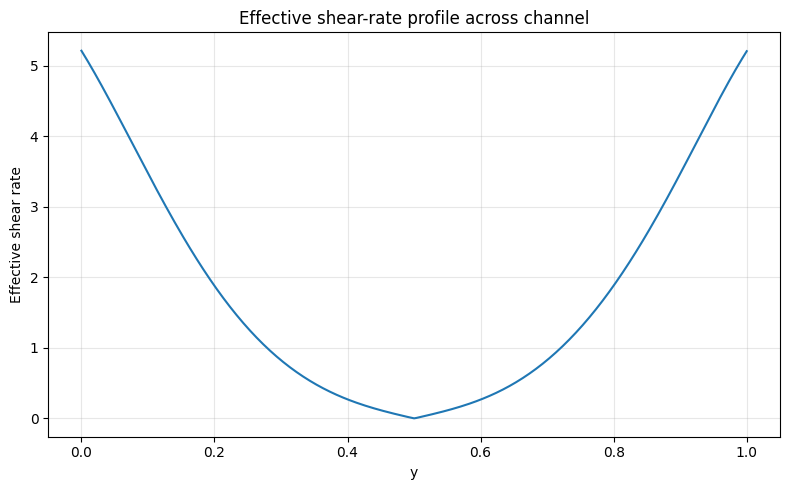

Saved: /kaggle/working/rheolnet_outputs/shear_rate_profile.png


In [24]:
# ===============================================================
# SHEAR-RATE PROFILE
# ===============================================================

plt.figure(figsize=(8, 5))
plt.plot(
    y_profile_np,
    gamma_profile_np,
)
plt.xlabel("y")
plt.ylabel("Effective shear rate")
plt.title("Effective shear-rate profile across channel")
plt.grid(True, alpha=0.3)
plt.tight_layout()

shear_plot_path = (
    OUTPUT_DIR
    / "shear_rate_profile.png"
)

plt.savefig(
    shear_plot_path,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print("Saved:", shear_plot_path)

## Cell 18B — Quantitative physical diagnostics

The direct metrics now use one consistent whole-profile relative-L2 symmetry definition for
`u`, viscosity, shear rate, and pressure. The exact-centre shear value is compared with both exact
wall values, and `max |v| / max |u|` is checked against the strict `0.001` gate.

Mirror-difference plots show exactly where any remaining viscosity or shear-rate asymmetry occurs.
The training objective does not directly penalize `eta` or `gamma`; it constrains `u`, `v`, and
`du/dy`, allowing rheology symmetry to follow from the velocity field.

Pressure variation across `y` is reported at `x = 0.25`, `0.50`, and `0.75`. The existing
pressure-vs-`x` plot and linearity calculation remain unchanged.


Largest |eta(y)-eta(1-y)| at y=0.400000: -1.301542e-04
Largest |gamma(y)-gamma(1-y)| at y=0.000000: 6.452084e-03


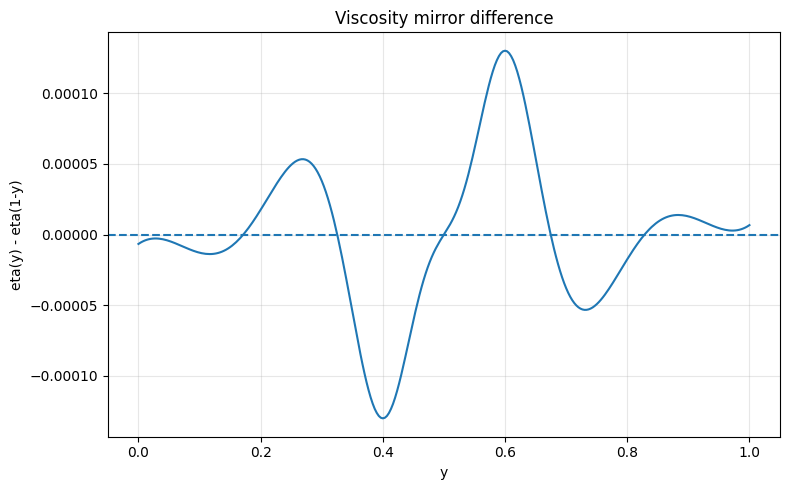

Saved: /kaggle/working/rheolnet_outputs/eta_mirror_difference.png


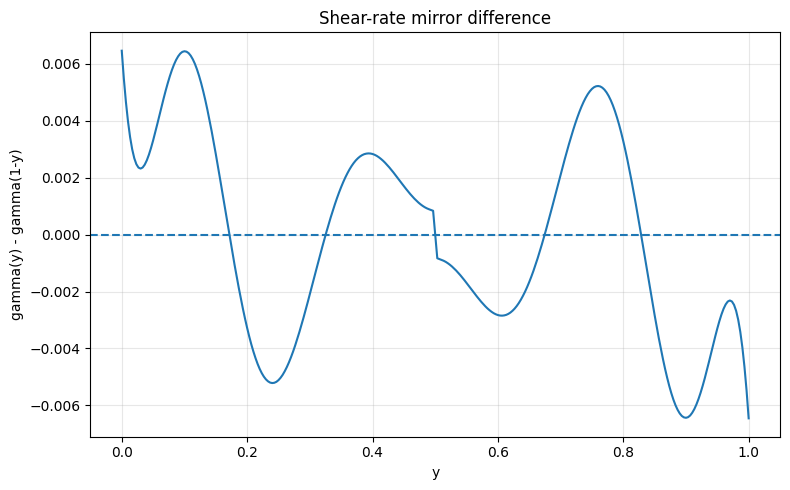

Saved: /kaggle/working/rheolnet_outputs/gamma_mirror_difference.png
QUANTITATIVE PHYSICAL DIAGNOSTICS
max|v|/max|u|                         : 4.250158e-04
u symmetry error (rel L2)             : 2.555638e-04
eta symmetry error (rel L2)           : 1.620350e-03
gamma symmetry error (rel L2)         : 1.469152e-03
p symmetry error (rel L2)             : 3.291137e-03
centre shear / wall shear             : 3.383285e-04
worst max |dp/dy|                     : 9.336352e-03
worst cross/axial pressure span       : 8.208028e-03
--------------------------------------------------------------------------------------
PASS   | max|v|/max|u|
PASS   | u symmetry error
PASS   | eta symmetry error
PASS   | gamma symmetry error
PASS   | centre shear / wall shear


In [25]:
# ===============================================================
# QUANTITATIVE PHYSICAL DIAGNOSTICS
# ===============================================================

eps_metric = 1e-12


def relative_mirror_l2(values):
    values = np.asarray(values, dtype=np.float64).reshape(-1)
    mirrored = values[::-1]
    return float(
        np.linalg.norm(values - mirrored)
        / max(np.linalg.norm(values), eps_metric)
    )


v_to_u_ratio = v_ratio
u_symmetry_error = relative_mirror_l2(u_profile)
eta_symmetry_error = relative_mirror_l2(eta_profile_np)
gamma_symmetry_error = relative_mirror_l2(gamma_profile_np)
p_symmetry_error = relative_mirror_l2(p_profile)

eta_mirror_difference = eta_profile_np - eta_profile_np[::-1]
gamma_mirror_difference = gamma_profile_np - gamma_profile_np[::-1]

eta_worst_idx = int(np.argmax(np.abs(eta_mirror_difference)))
gamma_worst_idx = int(np.argmax(np.abs(gamma_mirror_difference)))

print(
    "Largest |eta(y)-eta(1-y)| at y="
    f"{y_profile_np[eta_worst_idx]:.6f}: "
    f"{eta_mirror_difference[eta_worst_idx]:.6e}"
)
print(
    "Largest |gamma(y)-gamma(1-y)| at y="
    f"{y_profile_np[gamma_worst_idx]:.6f}: "
    f"{gamma_mirror_difference[gamma_worst_idx]:.6e}"
)

plt.figure(figsize=(8, 5))
plt.plot(y_profile_np, eta_mirror_difference)
plt.axhline(0.0, linestyle="--")
plt.xlabel("y")
plt.ylabel("eta(y) - eta(1-y)")
plt.title("Viscosity mirror difference")
plt.grid(True, alpha=0.3)
plt.tight_layout()
eta_mirror_path = OUTPUT_DIR / "eta_mirror_difference.png"
plt.savefig(eta_mirror_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", eta_mirror_path)

plt.figure(figsize=(8, 5))
plt.plot(y_profile_np, gamma_mirror_difference)
plt.axhline(0.0, linestyle="--")
plt.xlabel("y")
plt.ylabel("gamma(y) - gamma(1-y)")
plt.title("Shear-rate mirror difference")
plt.grid(True, alpha=0.3)
plt.tight_layout()
gamma_mirror_path = OUTPUT_DIR / "gamma_mirror_difference.png"
plt.savefig(gamma_mirror_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", gamma_mirror_path)

centre_shear_fraction = float(
    abs(centre_gamma)
    / max(wall_gamma_max, eps_metric)
)

physical_metrics = {
    "max|v|/max|u|": v_to_u_ratio,
    "u symmetry error (rel L2)": u_symmetry_error,
    "eta symmetry error (rel L2)": eta_symmetry_error,
    "gamma symmetry error (rel L2)": gamma_symmetry_error,
    "p symmetry error (rel L2)": p_symmetry_error,
    "centre shear / wall shear": centre_shear_fraction,
    "worst max |dp/dy|": max_abs_dpdy,
    "worst cross/axial pressure span": pressure_cross_to_axial,
}

physical_gates = {
    "max|v|/max|u|": v_to_u_ratio < cfg.v_to_u_target,
    "u symmetry error": u_symmetry_error < cfg.symmetry_target,
    "eta symmetry error": eta_symmetry_error < cfg.symmetry_target,
    "gamma symmetry error": (
        gamma_symmetry_error < cfg.symmetry_target
    ),
    "centre shear / wall shear": (
        centre_shear_fraction
        < cfg.centre_shear_fraction_target
    ),
}

print("=" * 86)
print("QUANTITATIVE PHYSICAL DIAGNOSTICS")
print("=" * 86)
for key, value in physical_metrics.items():
    print(f"{key:38s}: {value:.6e}")
print("-" * 86)
for key, passed in physical_gates.items():
    symbol = "PASS" if passed else "REVIEW"
    print(f"{symbol:6s} | {key}")
print("=" * 86)


## Cell 18C — Same-condition CY reference comparison

This comparison reuses the independent CY solution computed **before training** and used at the
inlet. It therefore compares the PINN and reference under the same channel size, rheology,
density/scaling, and prescribed bulk-flow condition.

Along with relative L2 error, it reports maximum absolute error, exact-centre error, wall error,
both bulk velocities, and their difference. The independent solver's Newtonian-limit self-check is
retained.


SAME-CONDITION FULLY-DEVELOPED CY REFERENCE CHECK
PINN bulk velocity                   : 6.674249e-01
CY reference bulk velocity           : 6.666570e-01
Bulk-velocity absolute difference    : 7.678545e-04
Bulk-velocity relative difference    : 1.151798e-03
CY reference pressure-gradient |G|   : 1.242218e-01
Newtonian solver self-check rel L2   : 2.500001e-07
PINN vs CY reference rel L2          : 3.446919e-03
Maximum absolute velocity error      : 5.155775e-03
Exact-centre velocity error          : 1.111936e-03
Maximum wall velocity error          : 3.501996e-04
Reference comparison gate             : PASS (target < 5.0%)


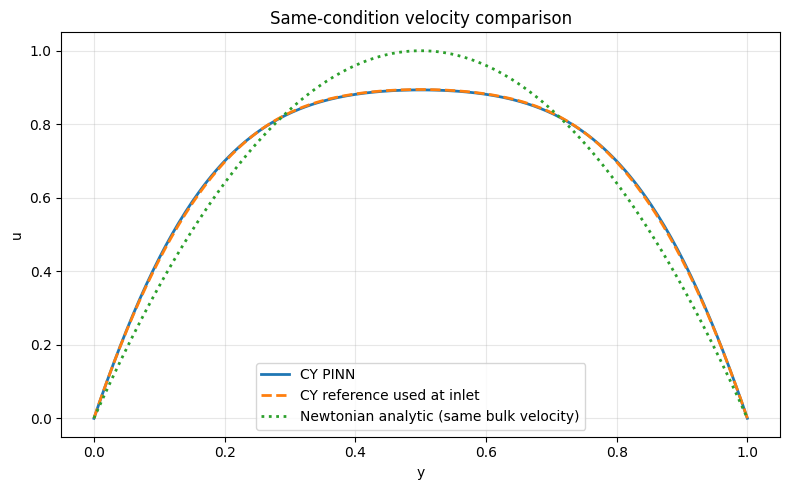

Saved: /kaggle/working/rheolnet_outputs/newtonian_vs_cy_reference_comparison.png


In [26]:
# ===============================================================
# SAME-CONDITION CY REFERENCE COMPARISON
# ===============================================================

channel_height = cfg.y_max - cfg.y_min
u_reference = np.interp(y_profile_np, y_ref, u_ref)

pinn_bulk_velocity = (
    profile_integral(u_profile, y_profile_np)
    / channel_height
)
reference_bulk_velocity = (
    profile_integral(u_reference, y_profile_np)
    / channel_height
)
bulk_velocity_abs_difference = abs(
    pinn_bulk_velocity - reference_bulk_velocity
)
bulk_velocity_rel_difference = (
    bulk_velocity_abs_difference
    / max(abs(reference_bulk_velocity), 1e-12)
)

velocity_abs_error = np.abs(u_profile - u_reference)
cy_reference_rel_l2 = float(
    np.linalg.norm(u_profile - u_reference)
    / max(np.linalg.norm(u_reference), 1e-12)
)
cy_reference_max_abs = float(np.max(velocity_abs_error))
cy_reference_center_abs = float(velocity_abs_error[centre_idx])
cy_reference_wall_abs = float(
    max(velocity_abs_error[0], velocity_abs_error[-1])
)
reference_gate = (
    cy_reference_rel_l2
    < cfg.reference_rel_l2_target
)

z_profile = (
    (y_profile_np - cfg.y_min)
    / channel_height
)
newtonian_analytic = (
    6.0
    * reference_bulk_velocity
    * z_profile
    * (1.0 - z_profile)
)

print("=" * 88)
print("SAME-CONDITION FULLY-DEVELOPED CY REFERENCE CHECK")
print("=" * 88)
print(f"PINN bulk velocity                   : {pinn_bulk_velocity:.6e}")
print(f"CY reference bulk velocity           : {reference_bulk_velocity:.6e}")
print(f"Bulk-velocity absolute difference    : {bulk_velocity_abs_difference:.6e}")
print(f"Bulk-velocity relative difference    : {bulk_velocity_rel_difference:.6e}")
print(f"CY reference pressure-gradient |G|   : {cy_inlet_reference['G']:.6e}")
print(f"Newtonian solver self-check rel L2   : {newtonian_selfcheck_rel_l2:.6e}")
print(f"PINN vs CY reference rel L2          : {cy_reference_rel_l2:.6e}")
print(f"Maximum absolute velocity error      : {cy_reference_max_abs:.6e}")
print(f"Exact-centre velocity error          : {cy_reference_center_abs:.6e}")
print(f"Maximum wall velocity error          : {cy_reference_wall_abs:.6e}")
print(
    "Reference comparison gate             :",
    "PASS" if reference_gate else "REVIEW",
    f"(target < {cfg.reference_rel_l2_target:.1%})",
)
print("=" * 88)

plt.figure(figsize=(8, 5))
plt.plot(
    y_profile_np,
    u_profile,
    linewidth=2,
    label="CY PINN",
)
plt.plot(
    y_profile_np,
    u_reference,
    linestyle="--",
    linewidth=2,
    label="CY reference used at inlet",
)
plt.plot(
    y_profile_np,
    newtonian_analytic,
    linestyle=":",
    linewidth=2,
    label="Newtonian analytic (same bulk velocity)",
)
plt.xlabel("y")
plt.ylabel("u")
plt.title("Same-condition velocity comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
comparison_plot_path = (
    OUTPUT_DIR
    / "newtonian_vs_cy_reference_comparison.png"
)
plt.savefig(comparison_plot_path, dpi=220, bbox_inches="tight")
plt.show()
print("Saved:", comparison_plot_path)


## Cell 19 — 2D field inspection

This is not required by Task 1.1, but it is valuable for spotting pathological PINN behavior that a
single centerline plot can hide.

A moderate grid is used because calculating non-Newtonian residuals requires autograd through the
stress field.

In [27]:
# ===============================================================
# 2D FIELD EVALUATION
# ===============================================================

model.eval()

n_grid = 60

x_grid = torch.linspace(
    cfg.x_min,
    cfg.x_max,
    n_grid,
    device=device,
)

y_grid = torch.linspace(
    cfg.y_min,
    cfg.y_max,
    n_grid,
    device=device,
)

Y, X = torch.meshgrid(
    y_grid,
    x_grid,
    indexing="ij",
)

xy_grid = torch.stack(
    [X.reshape(-1), Y.reshape(-1)],
    dim=1,
)

with torch.no_grad():
    pred_grid = model(xy_grid)

u_grid = (
    pred_grid[:, 0]
    .reshape(n_grid, n_grid)
    .cpu()
    .numpy()
)

v_grid = (
    pred_grid[:, 1]
    .reshape(n_grid, n_grid)
    .cpu()
    .numpy()
)

p_grid = (
    pred_grid[:, 2]
    .reshape(n_grid, n_grid)
    .cpu()
    .numpy()
)

xy_grid_grad = (
    xy_grid
    .clone()
    .detach()
    .requires_grad_(True)
)

(
    _,
    _,
    _,
    eta_grid,
    gamma_grid,
) = compute_ns_residuals_nonnewtonian(
    model=model,
    xy=xy_grid_grad,
    rho=cfg.rho,
    eta0=cfg.eta0,
    eta_inf=cfg.eta_inf,
    lam=cfg.lam,
    n=cfg.n,
    a=cfg.a,
)

eta_grid_np = (
    eta_grid
    .detach()
    .reshape(n_grid, n_grid)
    .cpu()
    .numpy()
)

gamma_grid_np = (
    gamma_grid
    .detach()
    .reshape(n_grid, n_grid)
    .cpu()
    .numpy()
)

extent = [
    cfg.x_min,
    cfg.x_max,
    cfg.y_min,
    cfg.y_max,
]

print("2D fields evaluated.")

2D fields evaluated.


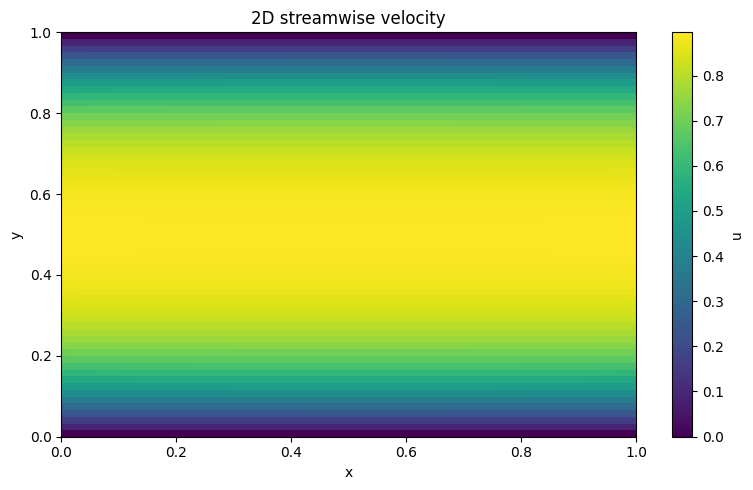

In [28]:
# ===============================================================
# 2D STREAMWISE VELOCITY
# ===============================================================

plt.figure(figsize=(8, 5))
img = plt.imshow(
    u_grid,
    origin="lower",
    extent=extent,
    aspect="auto",
)
plt.colorbar(img, label="u")
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D streamwise velocity")
plt.tight_layout()
plt.show()

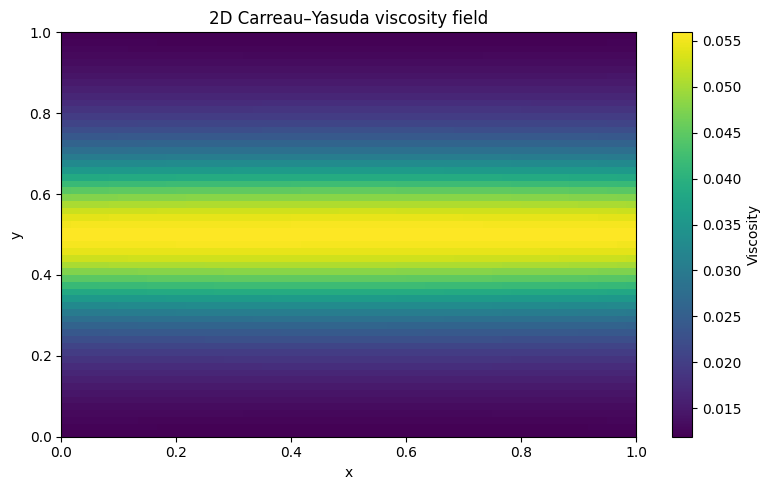

In [29]:
# ===============================================================
# 2D VISCOSITY
# ===============================================================

plt.figure(figsize=(8, 5))
img = plt.imshow(
    eta_grid_np,
    origin="lower",
    extent=extent,
    aspect="auto",
)
plt.colorbar(img, label="Viscosity")
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Carreau–Yasuda viscosity field")
plt.tight_layout()
plt.show()

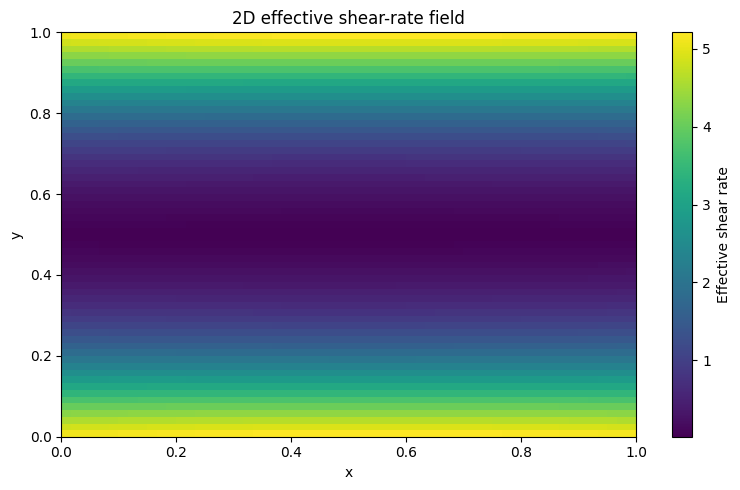

In [30]:
# ===============================================================
# 2D SHEAR RATE
# ===============================================================

plt.figure(figsize=(8, 5))
img = plt.imshow(
    gamma_grid_np,
    origin="lower",
    extent=extent,
    aspect="auto",
)
plt.colorbar(img, label="Effective shear rate")
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D effective shear-rate field")
plt.tight_layout()
plt.show()

## Cell 20 — Automated tests

For Task 1.1, the repository should contain:

```text
physics/tests/test_carreau_yasuda.py
physics/tests/test_navier_stokes_nonnewtonian.py
```

The second test should check the non-Newtonian residual itself, not only the viscosity function.

In [31]:
# ===============================================================
# PYTEST
# ===============================================================

import subprocess
import sys

test_files = [
    REPO_DIR / "physics" / "tests" / "test_carreau_yasuda.py",
    REPO_DIR / "physics" / "tests" / "test_navier_stokes_nonnewtonian.py",
]

missing_tests = [
    str(path)
    for path in test_files
    if not path.exists()
]

if missing_tests:
    print("Missing test files:")
    for path in missing_tests:
        print("  -", path)

    raise FileNotFoundError(
        "Task 1.1 tests are incomplete."
    )

result = subprocess.run(
    [
        sys.executable,
        "-m",
        "pytest",
        str(test_files[0]),
        str(test_files[1]),
        "-q",
    ],
    cwd=str(REPO_DIR),
    text=True,
)

if result.returncode != 0:
    raise RuntimeError(
        "One or more Task 1.1 tests failed."
    )

print("✓ Task 1.1 tests passed")

.............                                                            [100%]
13 passed in 2.33s
✓ Task 1.1 tests passed


## Cell 21 — Automatic Task 1.1 status report

This checks the software artifacts and the notebook outputs that can be verified automatically.

It does **not** replace scientific validation against CFD or a trusted reference solution.

In [32]:
# ===============================================================
# TASK 1.1 SOFTWARE + NUMERICAL READINESS REPORT
# ===============================================================

navier_file = REPO_DIR / "physics" / "navier_stokes.py"
test_ns_file = (
    REPO_DIR
    / "physics"
    / "tests"
    / "test_navier_stokes_nonnewtonian.py"
)

sig = inspect.signature(compute_ns_residuals_nonnewtonian)
params = set(sig.parameters)

software_checks = {
    "physics/navier_stokes.py exists": navier_file.exists(),
    "Residual receives model": "model" in params,
    "Residual receives xy": "xy" in params,
    "CY viscosity function imports": callable(
        carreau_yasuda_viscosity
    ),
    "Physics loss function imports": callable(
        navier_stokes_physics_loss
    ),
    "Non-Newtonian NS test file exists": test_ns_file.exists(),
    "Automated pytest suite passed": result.returncode == 0,
    "Viscosity profile was generated": (
        OUTPUT_DIR / "viscosity_day2.png"
    ).exists(),
    "Axial pressure plot was generated": (
        OUTPUT_DIR / "pressure_centreline_vs_x.png"
    ).exists(),
    "CY/Newtonian/reference plot was generated": (
        OUTPUT_DIR
        / "newtonian_vs_cy_reference_comparison.png"
    ).exists(),
    "eta mirror-difference plot was generated": (
        OUTPUT_DIR / "eta_mirror_difference.png"
    ).exists(),
    "gamma mirror-difference plot was generated": (
        OUTPUT_DIR / "gamma_mirror_difference.png"
    ).exists(),
}

reported_metric_values = np.array([
    rms_cont,
    rms_mx,
    rms_my,
    v_to_u_ratio,
    u_symmetry_error,
    eta_symmetry_error,
    gamma_symmetry_error,
    p_symmetry_error,
    centre_shear_fraction,
    pressure_linearity_r2,
    max_abs_dpdy,
    pressure_cross_to_axial,
    cy_reference_rel_l2,
    cy_reference_max_abs,
    cy_reference_center_abs,
    cy_reference_wall_abs,
    bulk_velocity_rel_difference,
], dtype=np.float64)
all_metrics_finite = bool(np.all(np.isfinite(reported_metric_values)))

numerical_checks = {
    "Fresh continuity RMS < 0.01": (
        rms_cont < cfg.residual_rms_target
    ),
    "Fresh momentum-x RMS < 0.01": (
        rms_mx < cfg.residual_rms_target
    ),
    "Fresh momentum-y RMS < 0.01": (
        rms_my < cfg.residual_rms_target
    ),
    "max|v|/max|u| < 0.001": (
        v_to_u_ratio < cfg.v_to_u_target
    ),
    "u symmetry error < 1%": (
        u_symmetry_error < cfg.symmetry_target
    ),
    "eta symmetry error < 1%": (
        eta_symmetry_error < cfg.symmetry_target
    ),
    "gamma symmetry error < 1%": (
        gamma_symmetry_error < cfg.symmetry_target
    ),
    "Centre shear / wall shear < 1%": (
        centre_shear_fraction
        < cfg.centre_shear_fraction_target
    ),
    "CY reference relative L2 < 5%": reference_gate,
    "Pressure-vs-x R^2 > 0.999": (
        pressure_linearity_r2 > cfg.pressure_r2_target
    ),
    "No NaN / Inf in reported metrics": all_metrics_finite,
}

print("=" * 92)
print("TASK 1.1 — SOFTWARE COMPLETION CHECK")
print("=" * 92)
for item, passed in software_checks.items():
    symbol = "✅" if passed else "❌"
    print(f"{symbol} {item}")
software_passed = all(software_checks.values())
print("-" * 92)
print(
    "SOFTWARE VERDICT:",
    "ACCEPTABLE ✅" if software_passed else "INCOMPLETE ❌",
)

print()
print("=" * 92)
print("NUMERICAL READINESS CHECK")
print("=" * 92)
for item, passed in numerical_checks.items():
    symbol = "✅" if passed else "🟡"
    print(f"{symbol} {item}")
numerical_passed = all(numerical_checks.values())
print("-" * 92)

if numerical_passed:
    print(
        "NUMERICAL VERDICT: every requested benchmark gate passed. "
        "The straight-channel result is suitable as a validated "
        "Task 1.1 benchmark."
    )
else:
    print(
        "NUMERICAL VERDICT: at least one strict benchmark gate still "
        "needs convergence/review. Do not describe the result as "
        "publication-validated yet."
    )

print()
print(
    "Important: the independent 1D solution validates this simple "
    "fully developed channel benchmark. A later realistic geometry "
    "still requires CFD/FEM comparison with consistent units/scaling."
)
print("=" * 92)


TASK 1.1 — SOFTWARE COMPLETION CHECK
✅ physics/navier_stokes.py exists
✅ Residual receives model
✅ Residual receives xy
✅ CY viscosity function imports
✅ Physics loss function imports
✅ Non-Newtonian NS test file exists
✅ Automated pytest suite passed
✅ Viscosity profile was generated
✅ Axial pressure plot was generated
✅ CY/Newtonian/reference plot was generated
✅ eta mirror-difference plot was generated
✅ gamma mirror-difference plot was generated
--------------------------------------------------------------------------------------------
SOFTWARE VERDICT: ACCEPTABLE ✅

NUMERICAL READINESS CHECK
✅ Fresh continuity RMS < 0.01
✅ Fresh momentum-x RMS < 0.01
✅ Fresh momentum-y RMS < 0.01
✅ max|v|/max|u| < 0.001
✅ u symmetry error < 1%
✅ eta symmetry error < 1%
✅ gamma symmetry error < 1%
✅ Centre shear / wall shear < 1%
✅ CY reference relative L2 < 5%
✅ Pressure-vs-x R^2 > 0.999
✅ No NaN / Inf in reported metrics
---------------------------------------------------------------------------

## Cell 22 — Optional Git workflow helper

Keep `PULL_NOW=False` during a normal run.

When you push updated `.py` files from your local machine to GitHub, set it to `True` once to pull
the newest branch into Kaggle. Because autoreload is enabled, subsequent notebook calls should use
the updated modules.

If imports behave strangely after a major class/module rewrite, restart the kernel.

In [33]:
# ===============================================================
# OPTIONAL GIT REFRESH
# ===============================================================

PULL_NOW = False

if PULL_NOW:
    subprocess.check_call(
        ["git", "pull", "origin", BRANCH],
        cwd=str(REPO_DIR),
    )

    print("Latest branch changes pulled.")
    print(
        "If you changed class definitions substantially, "
        "restart the kernel before continuing."
    )
else:
    print("Git pull skipped.")

Git pull skipped.


# What the results mean

## What changed in this optimized version

The Carreau–Yasuda implementation, imported non-Newtonian Navier–Stokes residual, 4×64 Tanh
architecture, strict P100 checks, device handling, and GPU RNG/checkpoint safety are unchanged.
The numerical workflow now implements the review directly:

- The former Newtonian parabolic inlet is replaced by a precomputed, bulk-matched fully developed
  Carreau–Yasuda reference inlet.
- Centreline points enforce both `v = 0` and `du/dy = 0` with weight `5.0` in Adam and L-BFGS.
- Whole-channel mirror pairs enforce symmetric `u`, antisymmetric `v`, and antisymmetric `du/dy`
  with weight `2.0`; no direct `eta` or `gamma` loss is added.
- Adam uses 256 freshly sampled mirror pairs at every step, while L-BFGS uses 1,024 fixed pairs.
- Adam uses 2,048 fresh interior points per step for 5,000 steps, with `1e-3` then `3e-4` learning
  rates.
- L-BFGS otherwise retains its fixed sets of 8,192 interior, 1,024 boundary, and 512 centreline
  points.
- Final PDE residuals are evaluated on 10,000 fresh points used only for validation.
- Pressure variation across `y` is checked at `x = 0.25`, `0.50`, and `0.75`; the existing
  pressure-vs-`x` plot and R² test are retained.
- Whole-profile relative-L2 symmetry is reported consistently for `u`, `eta`, `gamma`, and `p`.
- Saved `eta(y)-eta(1-y)` and `gamma(y)-gamma(1-y)` plots locate any remaining asymmetry.
- Shear is evaluated at the exact centre and exact top/bottom wall points.
- The same fixed CY solution used at the inlet is reused for post-training comparison, with
  relative L2, maximum, centre, wall, and bulk-flow errors.
- A new checkpoint name prevents a model trained without mirror symmetry from being mistaken for
  a compatible run.

All old cell outputs were cleared because they describe the previous objective. Run the notebook
from top to bottom to generate valid results for this configuration.

---

## What a successful Task 1.1 run proves

If the import checks, smoke test, training/refinement, unit tests, and numerical checklist pass, the
PINN is optimizing continuity and both momentum equations with local Carreau–Yasuda viscosity,
while satisfying the consistent CY inlet and the straight-channel symmetry conditions.

The strict gates intentionally remain unchanged. A `REVIEW` result means more convergence or
investigation is still required; the notebook does not lower a threshold to manufacture a pass.

---

## Remaining publication-level validation

Even when every benchmark gate passes, a realistic RheolNet study still needs consistent SI units
or a carefully derived nondimensional formulation, realistic geometry and boundary conditions,
and comparison with an external CFD/FEM solution for the same physical case.
